# Session 14: Project 2 — HR Analytics with AI-Assisted SQL

**Data Analytics in the Age of AI Bootcamp**

---

## Project Overview

**Business Scenario:** You are an HR data analyst at TechCorp, a mid-size technology company with 120 employees across 8 departments. Leadership has asked you to build an **AI-powered analytics tool** that lets anyone ask business questions in plain English and get back SQL queries, data results, and visualizations — no SQL knowledge required.

### What You Will Build

| Part | What You Build |
|------|---------------|
| **Part 1** | Load & explore an 8-table HR database |
| **Part 2** | Complete the Text-to-SQL engine (schema builder, validator, generator) |
| **Part 3** | Answer 12 business questions using your engine |
| **Part 4** | Build an LLM-powered auto-visualizer |
| **Part 5** | Prompt engineering — refine questions for better SQL |
| **Part 6** | Build a Streamlit web app with chat interface |
| **Part 7** | Reflection & analysis |


### Files Provided

| File | Description |
|------|-------------|
| `data/*.csv` | 8 CSV files (departments, job_titles, employees, salary_history, projects, project_assignments, performance_reviews, training_records) — 1,300+ rows total |
| `schema/SCHEMA.md` | Full schema documentation with ER diagram |
| `schema/er_diagram.mermaid` | Mermaid ER diagram (render at mermaid.live) |
| `db_utils.py` | **PROVIDED** — Database loading and schema inspection utilities |
| `text2sql_engine.py` | **YOUR WORK** — Text-to-SQL engine with 17 TODOs to complete |
| `text2sql_app.py` | **YOUR WORK** — Streamlit app with TODOs |
| `solution/` | Reference solutions (try on your own first!) |

### Prerequisites
Sessions 11-13 (SQL, Python-SQL Integration, Streamlit Basics)

---

# Part 1: Project Setup — Loading the HR Database

TechCorp's HR data lives in 8 CSV files. We will load them all into a SQLite in-memory database so we can query them with SQL.

In [1]:
# Core imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Our helper modules (db_utils is provided, text2sql_engine has your TODOs)
from db_utils import load_csv_to_db, get_schema_info, execute_query, list_tables, get_table_info, get_foreign_keys

print("All imports successful!")

All imports successful!


In [2]:
# Load all 8 CSV files into SQLite
conn = load_csv_to_db("data/")

# Show all tables and their row counts
print("\nDatabase Overview:")
print(list_tables(conn))

Loading 8 CSV files into database...
  ✓ departments: 8 rows, 6 columns
  ✓ employees: 120 rows, 13 columns
  ✓ job_titles: 38 rows, 6 columns
  ✓ performance_reviews: 293 rows, 7 columns
  ✓ project_assignments: 138 rows, 5 columns
  ✓ projects: 20 rows, 8 columns
  ✓ salary_history: 308 rows, 6 columns
  ✓ training_records: 418 rows, 9 columns

Database ready! 8 tables loaded.

Database Overview:
                 table  rows
0          departments     8
1            employees   120
2           job_titles    38
3  performance_reviews   293
4  project_assignments   138
5             projects    20
6       salary_history   308
7     training_records   418


## Explore the Schema

Before writing any queries, we need to understand the database. Open `schema/SCHEMA.md` for the full documentation and ER diagram.

Let's explore programmatically too:

In [3]:
# Display full schema with column types and sample data
schema = get_schema_info(conn)
print(schema)

DATABASE SCHEMA - TechCorp HR Analytics

TABLE: departments (8 rows)
--------------------------------------------------------------------------------
  dept_id                   INTEGER    (nullable)
  dept_name                 TEXT       (nullable)
  location                  TEXT       (nullable)
  annual_budget             INTEGER    (nullable)
  division                  TEXT       (nullable)
  established_date          TEXT       (nullable)

TABLE: employees (120 rows)
--------------------------------------------------------------------------------
  emp_id                    INTEGER    (nullable)
  first_name                TEXT       (nullable)
  last_name                 TEXT       (nullable)
  email                     TEXT       (nullable)
  dept_id                   INTEGER    (nullable)
  title_id                  INTEGER    (nullable)
  salary                    INTEGER    (nullable)
  hire_date                 TEXT       (nullable)
  gender                    TEXT       (

In [4]:
# Show how tables connect to each other (foreign key relationships)
fk_df = get_foreign_keys(conn)
print("\nTable Relationships:")
print(fk_df.to_string(index=False))

No formal foreign keys defined (relationships exist by naming convention).

Table Relationships:
         from_table from_column    to_table  to_column
          employees     dept_id departments    dept_id
          employees    title_id  job_titles   title_id
          employees  manager_id   employees     emp_id
           projects     dept_id departments    dept_id
project_assignments  project_id    projects project_id
project_assignments      emp_id   employees     emp_id
     salary_history      emp_id   employees     emp_id
performance_reviews      emp_id   employees     emp_id
   training_records      emp_id   employees     emp_id


In [5]:
# Peek at each table: first 3 rows
tables = ["departments", "job_titles", "employees", "salary_history",
          "projects", "project_assignments", "performance_reviews", "training_records"]

for table in tables:
    print(f"\n{'='*60}")
    print(f" {table.upper()} ")
    print(f"{'='*60}")
    df = execute_query(f"SELECT * FROM {table} LIMIT 3", conn)
    print(df.to_string(index=False))
    print(f"  ... {execute_query(f'SELECT COUNT(*) as total FROM {table}', conn)['total'][0]} rows total")


 DEPARTMENTS 
 dept_id   dept_name      location  annual_budget   division established_date
       1 Engineering San Francisco        3200000 Technology       2015-01-15
       2   Marketing      New York        1400000     Growth       2015-01-15
       3       Sales       Chicago        2100000    Revenue       2015-01-15
  ... 8 rows total

 JOB_TITLES 
 title_id                    title  dept_id     level  min_salary  max_salary
        1           VP Engineering        1 Executive      180000      220000
        2      Engineering Manager        1   Manager      150000      180000
        3 Senior Software Engineer        1    Senior      130000      160000
  ... 38 rows total

 EMPLOYEES 
 emp_id first_name last_name                        email  dept_id  title_id  salary  hire_date gender employment_status termination_date work_mode  manager_id
      1      James   Sanchez   james.sanchez@techcorp.com        1         1  196000 2016-07-17      M            Active             No

## Entity Relationship Diagram

The database has these key relationships:

```
departments ──┬── employees ──┬── salary_history
              │               ├── performance_reviews
              │               ├── training_records
              │               └── project_assignments ── projects
              │
              ├── job_titles
              └── projects

employees.manager_id → employees.emp_id  (self-referencing hierarchy)
```

**Key insight**: The `employees` table is the central hub. Most analytics questions will start there and JOIN to other tables.

In [6]:
# Warm-up queries to verify your understanding
# Run each and check the output makes sense

# How many active employees?
print("Active employees:")
print(execute_query("SELECT COUNT(*) as count FROM employees WHERE employment_status = 'Active'", conn))

# Departments and their employee counts
print("\nEmployees per department:")
print(execute_query("""
    SELECT d.dept_name, COUNT(e.emp_id) as emp_count
    FROM departments d
    LEFT JOIN employees e ON d.dept_id = e.dept_id
    GROUP BY d.dept_name
    ORDER BY emp_count DESC
""", conn))

# Average salary by career level
print("\nAverage salary by level:")
print(execute_query("""
    SELECT jt.level, ROUND(AVG(e.salary)) as avg_salary, COUNT(*) as count
    FROM employees e
    JOIN job_titles jt ON e.title_id = jt.title_id
    GROUP BY jt.level
    ORDER BY avg_salary DESC
""", conn))

Active employees:
   count
0    107

Employees per department:
          dept_name  emp_count
0       Engineering         25
1             Sales         20
2      Data Science         19
3           Finance         13
4         Marketing         12
5  Customer Support         12
6           Product         11
7   Human Resources          8

Average salary by level:
       level  avg_salary  count
0  Executive    180000.0      7
1    Manager    131714.0     14
2     Senior    125375.0     24
3        Mid    101020.0     50
4      Entry     68680.0     25


> **Takeaway**: You now have a rich, 8-table HR database with 1,300+ rows. The data includes employee demographics, compensation history, project assignments, performance reviews, and training records — enough to answer real business questions.

---

# Part 2: Building the Text-to-SQL Engine

Open `text2sql_engine.py` in your editor. It contains **17 TODOs** organized into 7 parts (A through G). You will implement the complete pipeline:

```
Question (English) → Schema Context → AI Prompt → Generated SQL → Safety Check → Execute → Results
```

Work through the TODOs in order. Each builds on the previous one.

## Part 2A: Schema Context Builder (TODOs 1-3)

The AI needs to understand your database to write correct SQL. The `get_schema_for_prompt()` function builds a text description of every table, column, and relationship.

**Why it matters**: A vague schema description → vague SQL. A detailed schema → accurate SQL.

Open `text2sql_engine.py` and complete TODOs 1, 2, and 3.

In [7]:
# Test your schema builder (after completing TODOs 1-3)
from text2sql_engine import get_schema_for_prompt

# Reload the module if you made changes
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import get_schema_for_prompt

schema_text = get_schema_for_prompt(conn)
print(schema_text[:2000])  # Print first 2000 chars
print(f"\n... (total length: {len(schema_text)} characters)")

# Verify: Does it include CREATE TABLE statements?
assert "CREATE TABLE" in schema_text, "Missing CREATE TABLE statements (TODO 1)"
# Verify: Does it include sample data?
assert "Sample" in schema_text or "sample" in schema_text, "Missing sample data (TODO 2)"
# Verify: Does it include relationships?
assert "->" in schema_text or "RELATIONSHIP" in schema_text.upper(), "Missing relationships (TODO 3)"

print("\nAll schema tests passed!")

CREATE TABLE departments (
    dept_id INTEGER,
    dept_name TEXT,
    location TEXT,
    annual_budget INTEGER,
    division TEXT,
    established_date TEXT
);

-- Sample data from departments:
--  dept_id   dept_name      location  annual_budget   division established_date
--        1 Engineering San Francisco        3200000 Technology       2015-01-15
--        2   Marketing      New York        1400000     Growth       2015-01-15
--        3       Sales       Chicago        2100000    Revenue       2015-01-15

CREATE TABLE employees (
    emp_id INTEGER,
    first_name TEXT,
    last_name TEXT,
    email TEXT,
    dept_id INTEGER,
    title_id INTEGER,
    salary INTEGER,
    hire_date TEXT,
    gender TEXT,
    employment_status TEXT,
    termination_date TEXT,
    work_mode TEXT,
    manager_id REAL
);

-- Sample data from employees:
--  emp_id first_name last_name                        email  dept_id  title_id  salary  hire_date gender employment_status termination_date work_m

## Part 2B: SQL Safety Validator (TODOs 4-6)

AI models can sometimes generate dangerous SQL (DROP TABLE, DELETE, etc.). Your validator must catch these before they reach the database.

Open `text2sql_engine.py` and complete TODOs 4, 5, and 6.

In [8]:
# Test your SQL validator (after completing TODOs 4-6)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import validate_sql

# These should all PASS (return True)
safe_queries = [
    "SELECT * FROM employees",
    "SELECT dept_name, AVG(salary) FROM employees e JOIN departments d ON e.dept_id = d.dept_id GROUP BY dept_name",
    "WITH dept_avg AS (SELECT dept_id, AVG(salary) as avg FROM employees GROUP BY dept_id) SELECT * FROM dept_avg",
]

for q in safe_queries:
    valid, msg = validate_sql(q)
    status = "PASS" if valid else "FAIL"
    print(f"  [{status}] Safe query: {q[:60]}... -> {msg}")
    assert valid, f"Should be valid: {q}"

# These should all FAIL (return False)
dangerous_queries = [
    "DROP TABLE employees",
    "DELETE FROM employees WHERE emp_id = 1",
    "UPDATE employees SET salary = 0",
    "INSERT INTO employees VALUES (999, 'Hacker')",
    "SELECT 1; DROP TABLE employees",
    "",
]

for q in dangerous_queries:
    valid, msg = validate_sql(q)
    status = "PASS" if not valid else "FAIL"
    print(f"  [{status}] Dangerous query: {q[:60]}... -> {msg}")
    assert not valid, f"Should be blocked: {q}"

print("\nAll validator tests passed!")

  [PASS] Safe query: SELECT * FROM employees... -> Query is safe.
  [PASS] Safe query: SELECT dept_name, AVG(salary) FROM employees e JOIN departme... -> Query is safe.
  [PASS] Safe query: WITH dept_avg AS (SELECT dept_id, AVG(salary) as avg FROM em... -> Query is safe.
  [PASS] Dangerous query: DROP TABLE employees... -> Query must start with SELECT or WITH
  [PASS] Dangerous query: DELETE FROM employees WHERE emp_id = 1... -> Query must start with SELECT or WITH
  [PASS] Dangerous query: UPDATE employees SET salary = 0... -> Query must start with SELECT or WITH
  [PASS] Dangerous query: INSERT INTO employees VALUES (999, 'Hacker')... -> Query must start with SELECT or WITH
  [PASS] Dangerous query: SELECT 1; DROP TABLE employees... -> Dangerous keyword detected: DROP
  [PASS] Dangerous query: ... -> Empty query.

All validator tests passed!


## Part 2C: Response Parser (TODOs 7-8)

When Gemini returns SQL, it might wrap it in markdown code blocks or add explanations. The parser extracts just the SQL.

Complete TODOs 7 and 8 in `text2sql_engine.py`.

In [9]:
# Test your response parser (after completing TODOs 7-8)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import extract_sql_from_response

# Test 1: SQL in code block
response1 = "Here's the query:\n```sql\nSELECT dept_name, AVG(salary) AS avg_salary\nFROM employees e\nJOIN departments d ON e.dept_id = d.dept_id\nGROUP BY dept_name;\n```\nThis joins the employees and departments tables."

sql1 = extract_sql_from_response(response1)
print(f"Test 1 (code block): {sql1[:60]}...")
assert "SELECT" in sql1 and "GROUP BY" in sql1

# Test 2: Plain SQL with explanation
response2 = "The SQL query to answer this is: SELECT COUNT(*) FROM employees WHERE employment_status = 'Active'; This counts all active employees."
sql2 = extract_sql_from_response(response2)
print(f"Test 2 (plain text): {sql2[:60]}...")
assert "SELECT" in sql2

# Test 3: Just SQL
response3 = "SELECT * FROM departments ORDER BY annual_budget DESC;"
sql3 = extract_sql_from_response(response3)
print(f"Test 3 (raw SQL): {sql3[:60]}...")
assert sql3.startswith("SELECT")

print("\nAll parser tests passed!")

Test 1 (code block): SELECT dept_name, AVG(salary) AS avg_salary
FROM employees e...
Test 2 (plain text): SELECT COUNT(*) FROM employees WHERE employment_status = 'Ac...
Test 3 (raw SQL): SELECT * FROM departments ORDER BY annual_budget DESC...

All parser tests passed!


## Part 2D-E: SQL Generator & Executor (TODOs 9-12)

Now for the core AI integration:
- **TODO 9**: Build the prompt that tells Gemini about the schema and rules
- **TODO 10**: Call the Gemini API and extract the SQL
- **TODO 11-12**: Validate and execute the generated SQL

Complete TODOs 9 through 12 in `text2sql_engine.py`.

In [10]:
# Set up the Claude API (you need this for TODOs 9-10 testing)
from anthropic import Anthropic
from dotenv import load_dotenv
import os

# Load API key from .env file
load_dotenv()
ANTHROPIC_API_KEY = os.getenv('ANTHROPIC_API_KEY')

# Initialize Claude client
client = Anthropic(api_key=ANTHROPIC_API_KEY)

# Quick test
resp = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=100,
    messages=[{"role": "user", "content": "Say hello in one word."}]
)
print(f"API test: {resp.content[0].text.strip()}")

API test: Hello!


In [11]:
# Test your SQL generator (after completing TODOs 9-12)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import generate_sql, execute_generated_sql, get_schema_for_prompt

schema_info = get_schema_for_prompt(conn)

# Test: Generate SQL for a simple question
sql = generate_sql("How many employees are in each department?", client, schema_info)
print(f"Generated SQL:\n{sql}\n")

# Test: Execute it
success, result = execute_generated_sql(sql, conn)
print(f"Success: {success}")
if success:
    print(result)
else:
    print(f"Error: {result}")

Generated SQL:
SELECT 
    d.dept_name,
    COUNT(e.emp_id) AS employee_count
FROM departments d
LEFT JOIN employees e ON d.dept_id = e.dept_id
WHERE e.employment_status = 'Active'
GROUP BY d.dept_id, d.dept_name
ORDER BY employee_count DESC

Success: True
          dept_name  employee_count
0       Engineering              24
1             Sales              18
2      Data Science              17
3           Finance              12
4           Product              11
5  Customer Support              10
6         Marketing               9
7   Human Resources               6


## Part 2F: Visualization Code Generator (TODOs 13-15)

This is where it gets exciting — the AI will write Python visualization code based on query results. Given a question, the SQL, and the resulting DataFrame, it generates matplotlib/seaborn code to create an appropriate chart.

Complete TODOs 13 through 15 in `text2sql_engine.py`.

Data to visualize:
          dept_name  employee_count
0       Engineering              25
1             Sales              20
2      Data Science              19
3           Finance              13
4         Marketing              12
5  Customer Support              12
6           Product              11
7   Human Resources               8

Generated Python code:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 7))

plt.bar(df['dept_name'], df['employee_count'], color='steelblue', edgecolor='black', linewidth=1.2)
plt.title('Number of Employees by Department', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='both', which='both', length=6, width=1.5)

for i, v in enumerate(df['employee_count']):
    plt.text(i, v + 0.3, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
fig = plt.gcf()


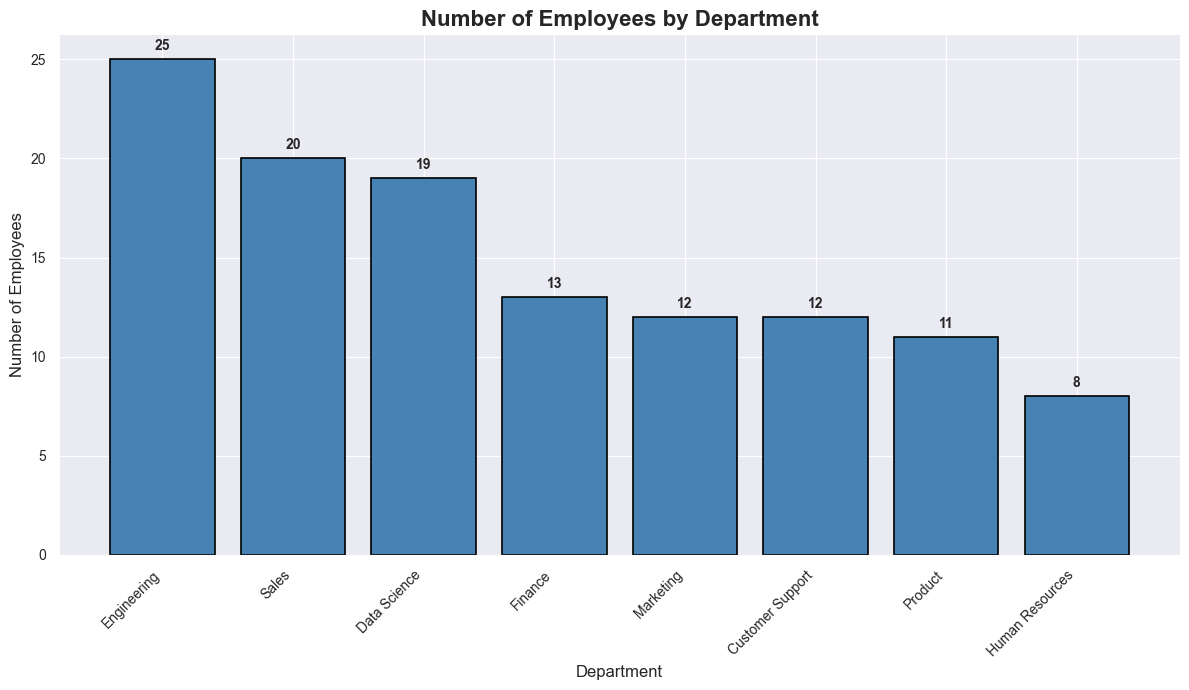


Visualization generated successfully!


In [12]:
# Test the visualization generator (after completing TODOs 13-15)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import generate_visualization_code

# First, get some data to visualize
test_sql = """
SELECT d.dept_name, COUNT(e.emp_id) as employee_count
FROM departments d
JOIN employees e ON d.dept_id = e.dept_id
GROUP BY d.dept_name
ORDER BY employee_count DESC
"""
test_df = pd.read_sql_query(test_sql, conn)
print("Data to visualize:")
print(test_df)

# Generate visualization code
viz_code = generate_visualization_code(
    "How many employees in each department?",
    test_sql,
    test_df,
    client
)
print(f"\nGenerated Python code:\n{viz_code}")

# Execute the visualization code
try:
    df = test_df  # Make 'df' available for the generated code
    exec(viz_code)
    if 'fig' in dir():
        plt.show()
    else:
        plt.show()
    print("\nVisualization generated successfully!")
except Exception as e:
    print(f"\nVisualization error: {e}")
    print("Check your generate_visualization_code() implementation.")

## Part 2G: The Complete Engine (TODOs 16-17)

Finally, wire everything together in the `Text2SQLEngine` class:
- **TODO 16**: Initialize the schema and Gemini client
- **TODO 17**: Implement the full `ask()` pipeline

Complete TODOs 16 and 17 in `text2sql_engine.py`.

Building schema context...
✓ Schema loaded: 5698 characters
Initializing Claude API...
✓ Claude API connected: ready

🤔 Question: How many total employees does TechCorp have?

📝 Generated SQL:
SELECT COUNT(*) AS total_employees
FROM employees
WHERE employment_status = 'Active'

✓ Query returned 1 rows

🧠 Generating interpretation...

💡 Insight: Based on the query results, TechCorp currently has 107 total employees, indicating the company is in the small-to-medium enterprise category within the technology sector. This workforce size suggests TechCorp has moved beyond the startup phase but still maintains the agility and close-knit culture typical of growing tech companies.

**Key insight:** With 107 employees, TechCorp is at a critical scaling point where organizational structure and processes become increasingly important for sustained growth.

**Actionable recommendation:** Consider implementing formal departmental structures and standardized HR processes now, as companies typically e

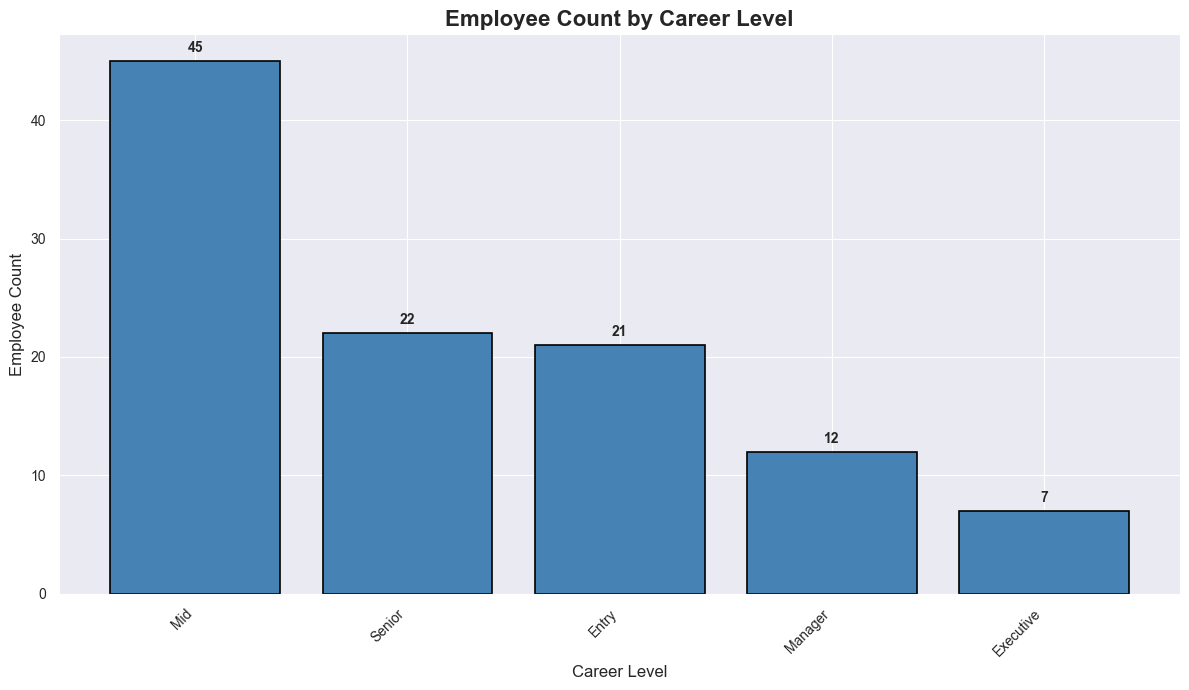

In [13]:
# Test the complete engine (after completing TODOs 16-17)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import Text2SQLEngine

# Create the engine with Claude API
engine = Text2SQLEngine(conn, api_key=ANTHROPIC_API_KEY)

# Test 1: Simple count
result = engine.ask("How many total employees does TechCorp have?")
print(f"\nSuccess: {result['success']}")

# Test 2: Aggregation with GROUP BY
result = engine.ask("What is the average salary by department? Include department name.")
print(f"\nSuccess: {result['success']}")

# Test 3: With visualization
result = engine.ask("Show employee count by career level", visualize=True)
if result.get('viz_code'):
    print(f"\nVisualization code generated ({len(result['viz_code'])} chars)")
    try:
        df = result['data']  # Make df available for the viz code
        exec(result['viz_code'])
        plt.show()
    except Exception as e:
        print(f"Viz error: {e}")
        print(f"\nGenerated code:\n{result['viz_code']}")  # Debug: show what was generated
        print(f"\nDataFrame columns: {result['data'].columns.tolist()}")  # Debug: show actual columns

> **Takeaway**: You've built a complete AI-powered SQL engine from scratch\! The key insight is that each component (schema builder, validator, parser, generator, executor, visualizer) does one thing well, and the engine ties them all together. This modular design makes it easy to test, debug, and improve each piece independently.

---

# Part 3: Answer 12 Business Questions

Now use your completed engine to answer real business questions. For each question:

1. **Ask** the engine using `engine.ask()`
2. **Review** the generated SQL — is it correct?
3. **Visualize** the results (use the engine's viz or write your own)
4. **Insight** — write a 1-2 sentence business takeaway

**Tip**: If the AI generates incorrect SQL, refine your question and try again. Learning to prompt effectively IS the skill here.

## Question 1: Compensation Overview

*What is the average, minimum, and maximum salary for each department? Include the number of employees.*

**Visualization hint**: Bar chart comparing departments


🤔 Question: 
What is the average, minimum, and maximum salary for each department? 
Include the number of employees.
Create a grouped bar chart comparing average, minimum, and maximum salary for each department.


📝 Generated SQL:
SELECT 
    d.dept_name,
    ROUND(AVG(e.salary), 2) AS avg_salary,
    MIN(e.salary) AS min_salary,
    MAX(e.salary) AS max_salary,
    COUNT(e.emp_id) AS employee_count
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
WHERE e.employment_status = 'Active'
GROUP BY d.dept_id, d.dept_name
ORDER BY avg_salary DESC

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: ## Salary Analysis by Department

**Key Insight:** Data Science leads in compensation with the highest average salary at $140,176, followed by Product ($125,727) and Engineering ($121,958), while Customer Support has the lowest average at $69,000 - creating a significant $71,176 gap between the highest and lowest-paid departments.

**Actionable Recommendation:** The com

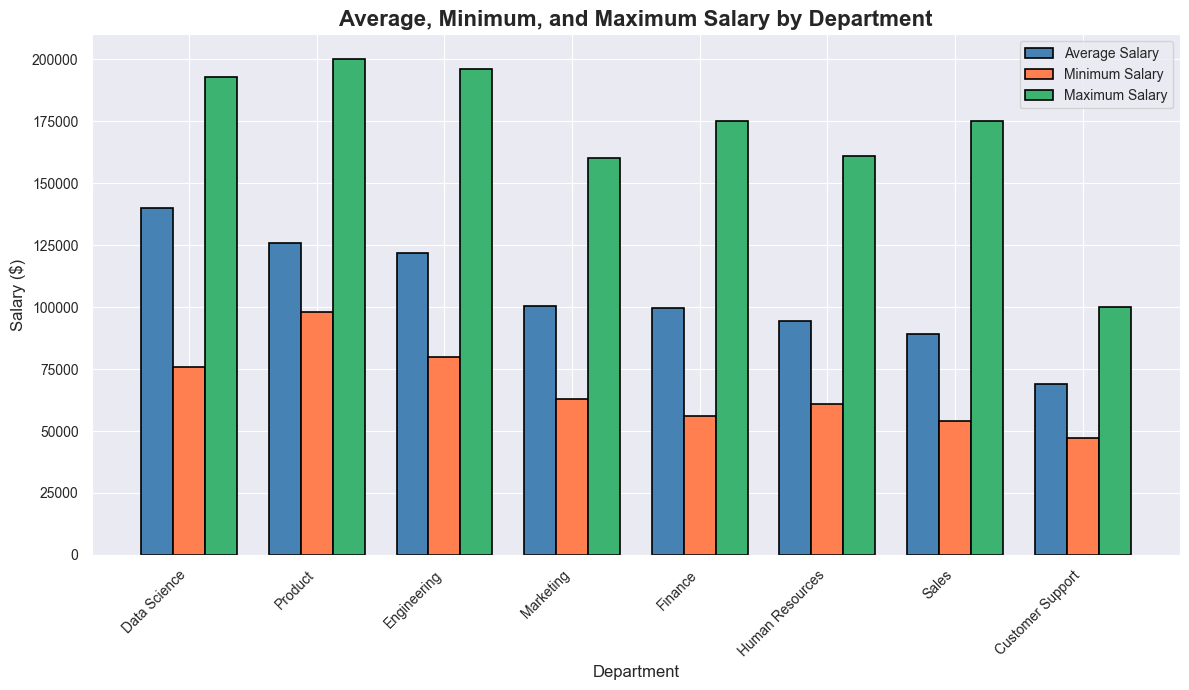

✓ Visualization generated successfully


In [14]:
# Question 1: Compensation Overview
result_q1 = engine.ask('''
What is the average, minimum, and maximum salary for each department? 
Include the number of employees.
Create a grouped bar chart comparing average, minimum, and maximum salary for each department.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q1['data'])

# NEW: Use safe_visualize instead of manual exec
from db_utils import safe_visualize
safe_visualize(result_q1)

In [15]:
# Business Insight for Question 1
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q1, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Departmental Salary Analysis Reveals Significant Compensation Disparities

Key Findings:
- Data Science leads compensation with an average salary of $140,176.47, while Customer Support trails at $69,000.00 - a gap of over $71,000 between highest and lowest paying departments
- Engineering represents our largest department with 24 employees but ranks only 3rd in average compensation at $121,958.33
- Sales has the second-largest headcount (18 employees) but the second-lowest average salary at $89,000.00, creating potential retention risks
- Customer Support shows the narrowest salary range ($47,000-$100,000) while Product has the widest spread ($98,000-$200,000)

Observations:
- Technical departments (Data Science, Product, Engineering) consistently outpace business functions by $20,000-$50,000 in average compensation, reflecting market premiums for technical talent
- Despite having smaller teams, specialized departments like Data Scienc

## Question 2: Pay Equity by Gender

*Compare the average salary between male and female employees, broken down by career level (from job_titles).*

**Visualization hint**: Grouped bar chart: level x gender


🤔 Question: 
Compare the average salary between male and female employees, 
broken down by career level.
Create a grouped bar chart with career levels on the x-axis and separate bars for male and female employees. Avoid using traditional gender color stereotypes (e.g., pink/blue). Instead, use a modern palette that is visually appealing and accessible to all viewers.


📝 Generated SQL:
SELECT 
    jt.level AS career_level,
    e.gender,
    ROUND(AVG(e.salary), 2) AS avg_salary
FROM employees e
JOIN job_titles jt ON e.title_id = jt.title_id
WHERE e.employment_status = 'Active'
    AND e.gender IN ('M', 'F')
GROUP BY jt.level, e.gender
ORDER BY 
    CASE jt.level
        WHEN 'Executive' THEN 1
        WHEN 'Manager' THEN 2
        WHEN 'Senior' THEN 3
        WHEN 'Mid' THEN 4
        WHEN 'Junior' THEN 5
        ELSE 6
    END,
    e.gender

✓ Query returned 10 rows

🧠 Generating interpretation...

💡 Insight: Looking at this salary data, there's a notable gender pay gap that varies s

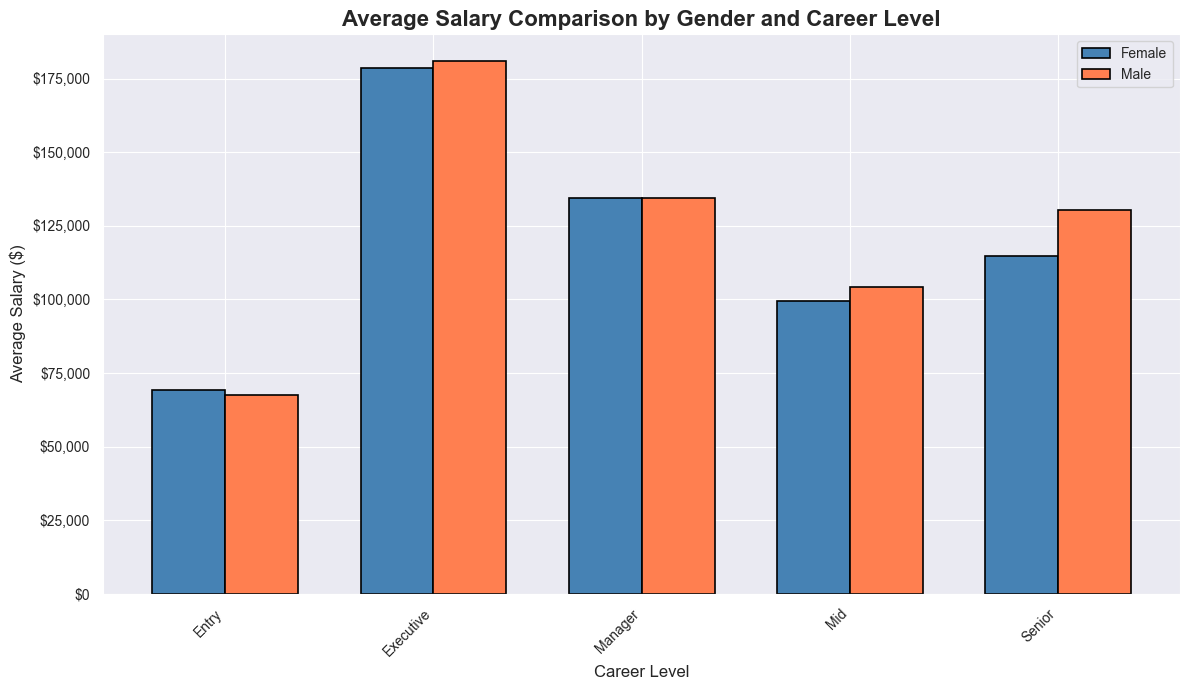

✓ Visualization generated successfully


In [16]:
# Question 2: Pay Equity by Gender
result_q2 = engine.ask('''
Compare the average salary between male and female employees, 
broken down by career level.
Create a grouped bar chart with career levels on the x-axis and separate bars for male and female employees. Avoid using traditional gender color stereotypes (e.g., pink/blue). Instead, use a modern palette that is visually appealing and accessible to all viewers.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q2['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q2)

In [17]:
# Business Insight for Question 2
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q2, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Gender Pay Gap Analysis Across Career Levels

Key Findings:
- Male employees earn more than female employees at Senior ($130,200 vs $114,857) and Mid-level ($104,130 vs $99,455) positions, representing gaps of $15,343 and $4,676 respectively.
- Female employees slightly out-earn males at Executive ($178,667 vs $181,000), Manager ($134,600 vs $134,286), and Entry levels ($69,167 vs $67,667), though differences are minimal.
- The largest absolute pay gap occurs at the Senior level where men earn 13.4% more than women.
- Executive compensation shows the smallest gap with less than $2,400 difference between genders.

Observations:
- Pay equity appears strongest at entry and executive levels, suggesting potential bias emerges during mid-career progression phases.
- The Senior level represents a critical inflection point where the gender pay gap is most pronounced, potentially impacting career advancement decisions.
- Manager-level compensat

## Question 3: Top Performers vs. Compensation

*For employees with a 2024 performance rating of 4 or 5, what is their average salary compared to those rated 1-3? Break it down by department.*

**Visualization hint**: Show the gap between high and low performers


🤔 Question: 
For employees with a 2024 performance rating of 4 or 5, 
what is their average salary compared to those rated 1-3? 
Break it down by department.
Create a grouped bar chart comparing high performers (rating 4-5) vs average/low performers (rating 1-3) side by side for each department.


📝 Generated SQL:
SELECT 
    d.dept_name,
    CASE 
        WHEN pr.rating IN (4, 5) THEN 'High Performers (4-5)'
        ELSE 'Average/Low Performers (1-3)'
    END AS performance_group,
    ROUND(AVG(e.salary), 2) AS avg_salary,
    COUNT(*) AS employee_count
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
JOIN performance_reviews pr ON e.emp_id = pr.emp_id
WHERE pr.review_year = 2024 
    AND e.employment_status = 'Active'
    AND pr.rating BETWEEN 1 AND 5
GROUP BY d.dept_name, 
    CASE 
        WHEN pr.rating IN (4, 5) THEN 'High Performers (4-5)'
        ELSE 'Average/Low Performers (1-3)'
    END
ORDER BY d.dept_name, performance_group;

✓ Query returned 16 rows

🧠 Genera

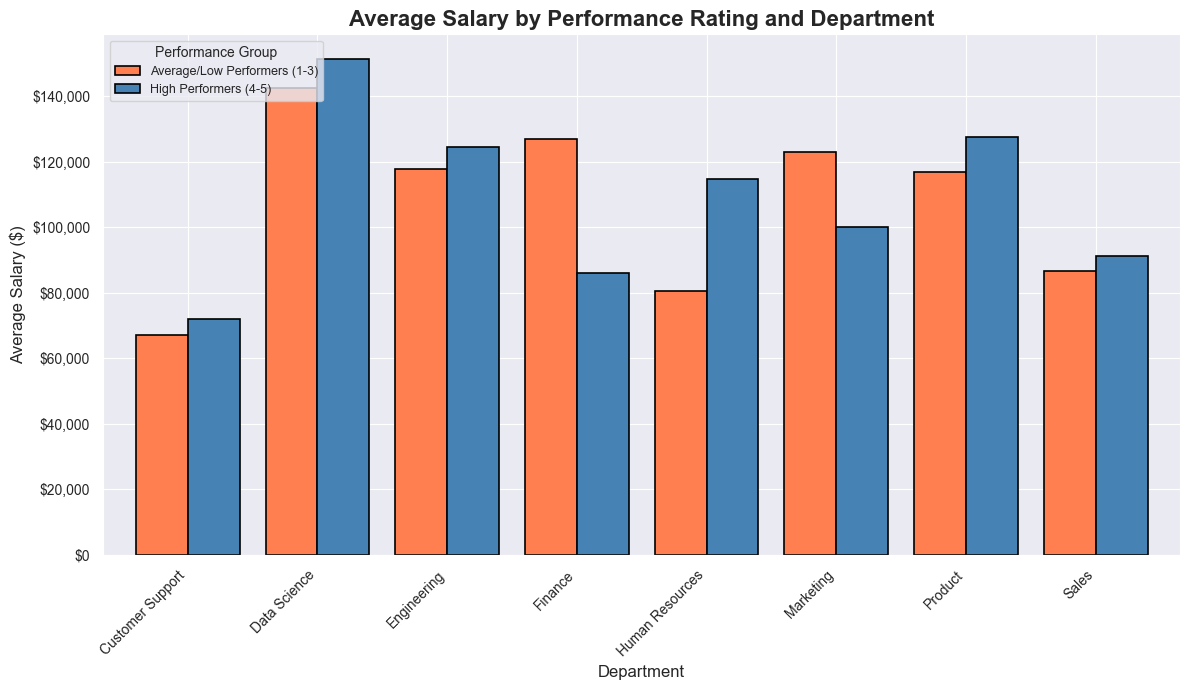

✓ Visualization generated successfully


In [18]:
# Question 3: Top Performers vs. Compensation
result_q3 = engine.ask('''
For employees with a 2024 performance rating of 4 or 5, 
what is their average salary compared to those rated 1-3? 
Break it down by department.
Create a grouped bar chart comparing high performers (rating 4-5) vs average/low performers (rating 1-3) side by side for each department.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q3['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q3)

In [19]:
# Business Insight for Question 3
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q3, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Performance-Based Salary Analysis Reveals Compensation Misalignment

Key Findings:
- Finance shows a concerning inverse relationship with high performers earning $41,000 less than average/low performers ($86,000 vs $127,000), representing a 32% pay gap disadvantaging top talent
- Data Science demonstrates the strongest positive correlation between performance and pay, with high performers earning $8,833 more on average ($151,333 vs $142,500)
- Customer Support has the lowest overall salary ranges but maintains proper alignment with high performers earning $5,000 more than lower performers
- Engineering leads in high performer retention with 15 top-rated employees earning $6,511 more than their lower-performing colleagues

Observations:
- Finance and Marketing departments both show negative correlations between performance and salary, creating significant retention risks for top talent in these critical business functions
- Technical de

## Question 4: Hiring Trends Over Time

*How many employees were hired each year? Show the trend from 2015 to 2025.*

**Visualization hint**: Line chart showing hiring over time


🤔 Question: 
How many employees were hired each year? 
Show the trend from 2015 to 2025.
Create a line chart showing hiring trends over time with years on the x-axis and number of hires on the y-axis.


📝 Generated SQL:
SELECT 
    CAST(strftime('%Y', hire_date) AS INTEGER) AS hire_year,
    COUNT(*) AS hires_count
FROM employees e
WHERE hire_date IS NOT NULL
    AND CAST(strftime('%Y', hire_date) AS INTEGER) BETWEEN 2015 AND 2025
GROUP BY CAST(strftime('%Y', hire_date) AS INTEGER)
ORDER BY hire_year

✓ Query returned 11 rows

🧠 Generating interpretation...

💡 Insight: **Key Insight:** The company experienced significant growth in hiring from 2017-2021, peaking at 25 hires in 2021, but has seen a sharp decline since then, dropping to just 9 hires in 2024 and 3 in 2025.

**Business Interpretation:** The hiring trend shows a clear growth phase from 2015-2021 (increasing from 2 to 25 annual hires), followed by a concerning downward trend from 2022-2025 (decreasing from 18 to 3 hires). Th

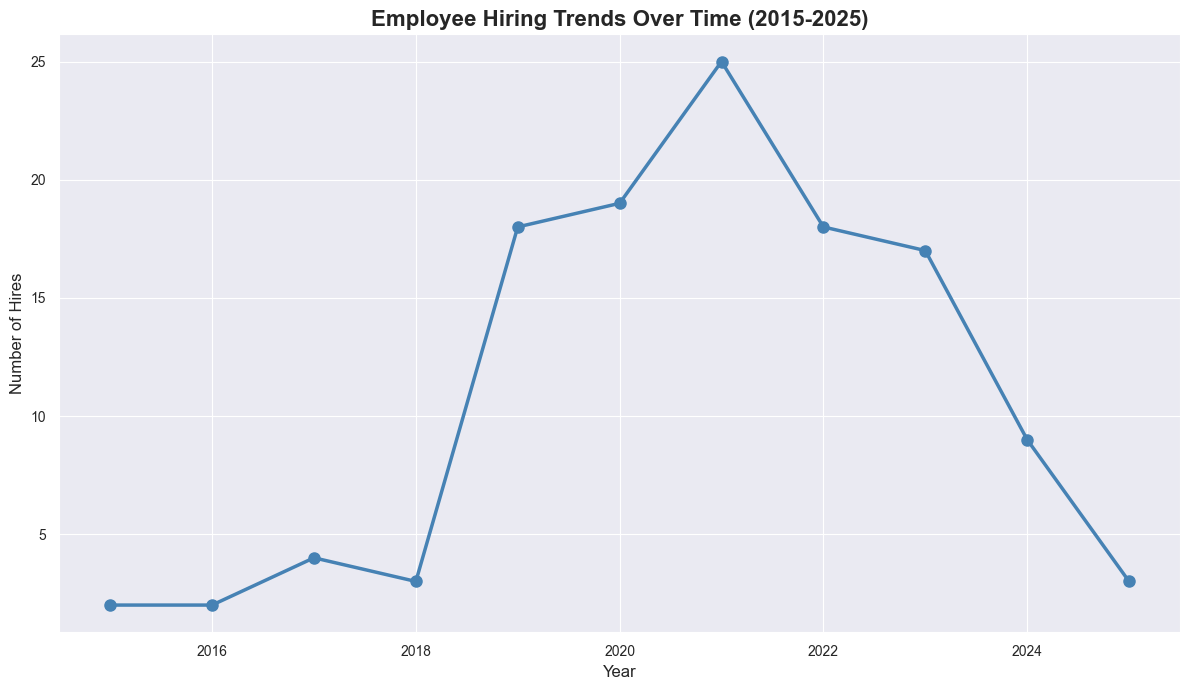

✓ Visualization generated successfully


In [20]:
# Question 4: Hiring Trends Over Time
result_q4 = engine.ask('''
How many employees were hired each year? 
Show the trend from 2015 to 2025.
Create a line chart showing hiring trends over time with years on the x-axis and number of hires on the y-axis.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q4['data'])

from db_utils import safe_visualize
safe_visualize(result_q4)

In [21]:
# Business Insight for Question 4
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q4, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Employee Hiring Trends Analysis (2015-2025)

Key Findings:
- TechCorp experienced dramatic hiring growth from 2015-2021, peaking at 25 hires in 2021 (a 1,150% increase from 2015's 2 hires)
- Total hiring volume reached 120 employees over the 11-year period, with 62% of all hires occurring during the high-growth period of 2019-2021 (62 employees)
- Hiring has declined significantly since 2021, dropping 64% to just 9 hires in 2024
- The 2025 projection of 3 hires would represent the second-lowest hiring year in the dataset, matching early-stage company levels

Observations:
- The company shows a clear growth phase (2019-2021) followed by a contraction phase (2022-2025), suggesting potential market challenges or strategic shifts
- Pre-2019 hiring was minimal and steady (2-4 hires annually), indicating TechCorp was likely in startup or early-stage mode during 2015-2018
- The sharp decline from 25 hires (2021) to 18 hires (2022) marks the b

## Question 5: Salary Growth Analysis

*What is the average total salary increase (from first to latest salary in salary_history) per department? Which department gives the biggest raises?*

**Visualization hint**: Horizontal bar chart


🤔 Question: 
What is the average total salary increase (from first to latest salary in salary_history) 
per department? Which department gives the biggest raises?
Create a horizontal bar chart showing average salary increase by department, sorted from highest to lowest.


📝 Generated SQL:
SELECT 
    d.dept_name,
    ROUND(AVG(salary_increase), 2) AS avg_salary_increase
FROM (
    SELECT 
        e.dept_id,
        e.emp_id,
        MAX(sh.new_salary) - MIN(sh.old_salary) AS salary_increase
    FROM employees e
    JOIN salary_history sh ON e.emp_id = sh.emp_id
    GROUP BY e.dept_id, e.emp_id
    HAVING COUNT(sh.history_id) > 0
) emp_increases
JOIN departments d ON emp_increases.dept_id = d.dept_id
GROUP BY d.dept_id, d.dept_name
ORDER BY avg_salary_increase DESC

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: **Business Interpretation:**

Data Science leads in salary growth with an average increase of $28,467, followed closely by Human Resources at $25,833, whil

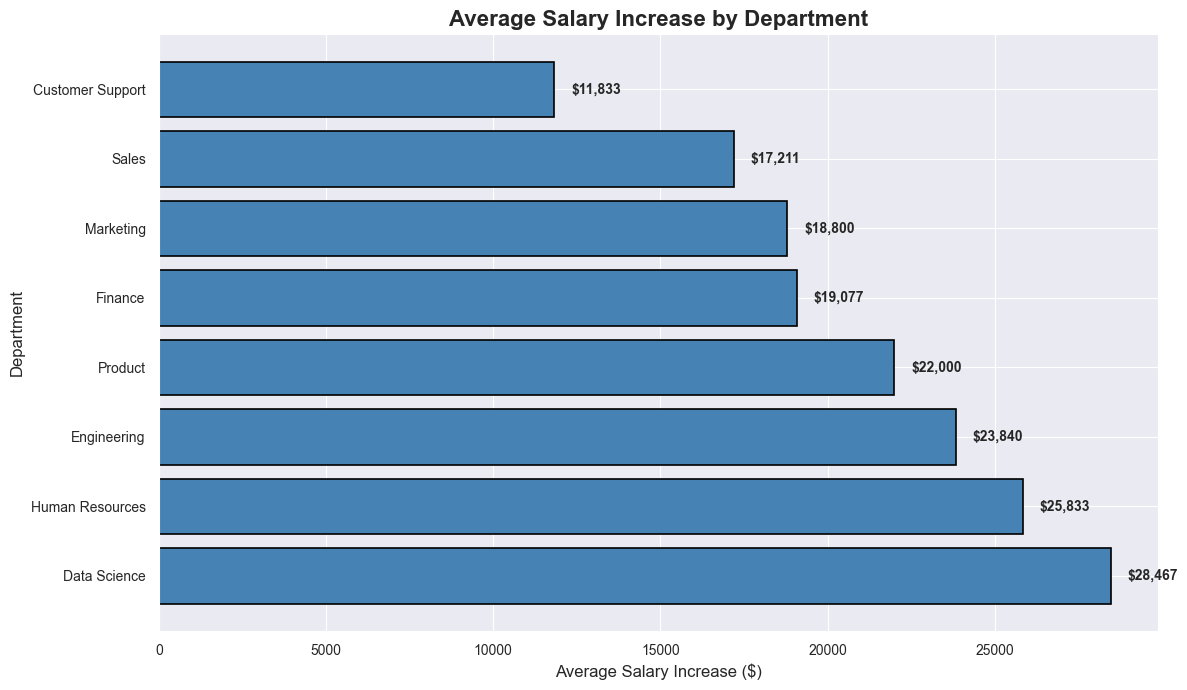

✓ Visualization generated successfully


In [22]:
# Question 5: Salary Growth Analysis
result_q5 = engine.ask('''
What is the average total salary increase (from first to latest salary in salary_history) 
per department? Which department gives the biggest raises?
Create a horizontal bar chart showing average salary increase by department, sorted from highest to lowest.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q5['data'])

from db_utils import safe_visualize
safe_visualize(result_q5)

In [23]:
# Business Insight for Question 5
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q5, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Department Salary Increase Analysis

Key Findings:
- Data Science leads with the highest average salary increases at $28,466.67, followed closely by Human Resources at $25,833.33
- Customer Support shows significantly lower salary growth at $11,833.33, representing 58% less than the top-performing department
- There's a $16,633.34 gap between the highest (Data Science) and lowest (Customer Support) average salary increases across departments
- Sales department, despite being revenue-generating, ranks second-lowest at $17,210.53 average increase

Observations:
- Technical and strategic departments (Data Science, HR, Engineering) consistently outpace customer-facing departments in salary progression
- The salary increase disparity suggests potential retention risks in lower-growth departments like Customer Support and Sales
- Product and Finance departments fall in the middle range ($19K-$22K), indicating moderate but consistent salary g

## Question 6: Project Staffing & Budget

*For each active project, show the project name, budget, number of team members, and budget per team member. Which projects are most/least resourced?*

**Visualization hint**: Bar chart of budget per head


🤔 Question: 
For each active project, show the project name, budget, number of team members, 
and budget per team member. Which projects are most or least resourced?
Create a bar chart showing budget per team member for each project, sorted from highest to lowest.


📝 Generated SQL:
SELECT 
    p.project_name,
    p.budget,
    COUNT(pa.emp_id) AS team_members,
    ROUND(CAST(p.budget AS REAL) / COUNT(pa.emp_id), 2) AS budget_per_member
FROM projects p
JOIN project_assignments pa ON p.project_id = pa.project_id
WHERE p.status IN ('Active', 'In Progress')
GROUP BY p.project_id, p.project_name, p.budget
ORDER BY budget_per_member DESC;

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: **Key Insight:** There's a significant resource allocation disparity across active projects, with budget per team member ranging from $100,000 (ML Recommendation Engine) to just $13,571 (Social Media Expansion and Budget Forecasting Tool) - a 7x difference.

**Actionable Recommendation:*

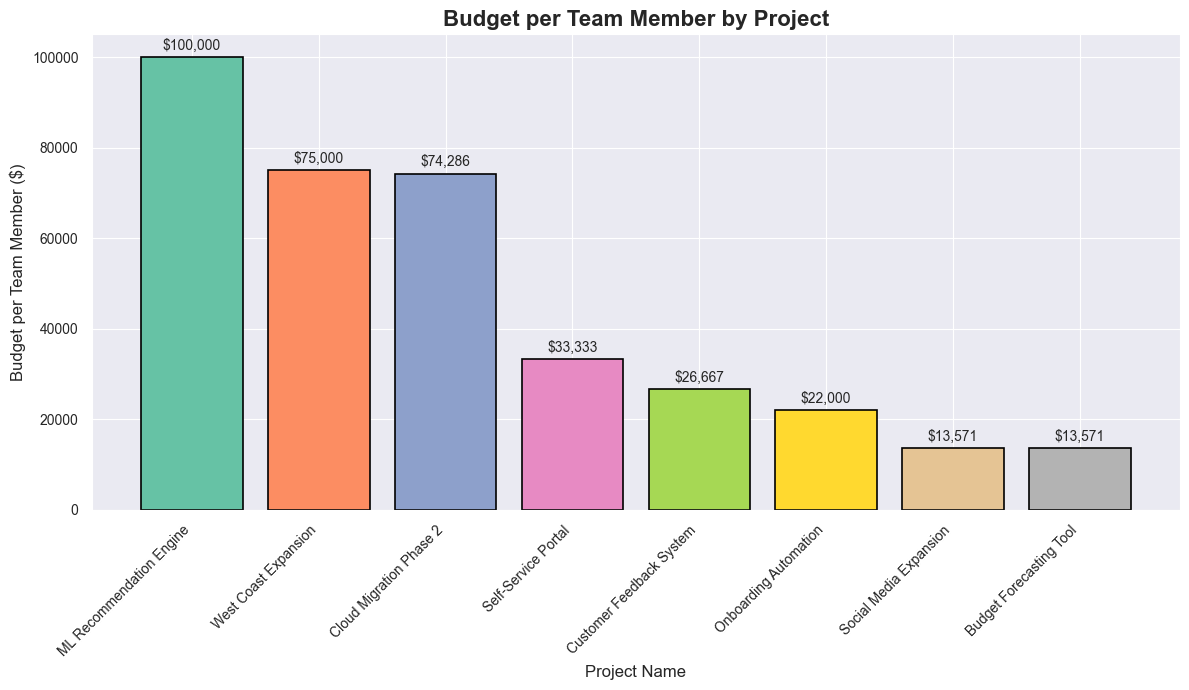

✓ Visualization generated successfully


In [24]:
# Question 6: Project Staffing & Budget
result_q6 = engine.ask('''
For each active project, show the project name, budget, number of team members, 
and budget per team member. Which projects are most or least resourced?
Create a bar chart showing budget per team member for each project, sorted from highest to lowest.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q6['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q6)

In [25]:
# Business Insight for Question 6
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q6, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Project Resource Allocation Analysis

Key Findings:
- ML Recommendation Engine is the most resourced project at $100,000 per team member, significantly higher than the average of $44,803 per member across all projects
- Two projects (Social Media Expansion and Budget Forecasting Tool) are severely under-resourced at only $13,571 per team member each
- There's a dramatic 7.4x difference between the highest and lowest resourced projects, indicating major resource allocation inconsistencies
- West Coast Expansion and Cloud Migration Phase 2 represent mid-tier resource allocation at $75,000 and $74,286 per member respectively

Observations:
- Higher budget projects don't necessarily correlate with higher per-member allocation, as Cloud Migration Phase 2 has the largest total budget ($520,000) but ranks third in per-member resources
- Four projects fall below $30,000 per team member, suggesting potential resource constraints that could impa

## Question 7: Remote Work Distribution

*How does work mode (Remote/Hybrid/On-site) vary across departments? Show the count for each combination.*

**Visualization hint**: Stacked bar chart or heatmap


🤔 Question: 
How does work mode (Remote/Hybrid/On-site) vary across departments? 
Show the count for each combination.
Create a stacked bar chart showing the distribution of work modes within each department.
Also Create a heatmap showing the distribution of work modes within each department.
Side by side


📝 Generated SQL:
SELECT 
    d.dept_name,
    e.work_mode,
    COUNT(*) AS employee_count
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
WHERE e.employment_status = 'Active'
GROUP BY d.dept_name, e.work_mode
ORDER BY d.dept_name, e.work_mode

✓ Query returned 22 rows

🧠 Generating interpretation...

💡 Insight: Looking at the work mode distribution across departments, **Engineering shows the most flexibility with equal split between Remote (9) and Hybrid (9) workers, while Sales leans heavily toward On-site work (8 out of 18 employees)**. Notably, Marketing and Product departments have no On-site employees, operating entirely in Remote/Hybrid models.

**Key insight**: 

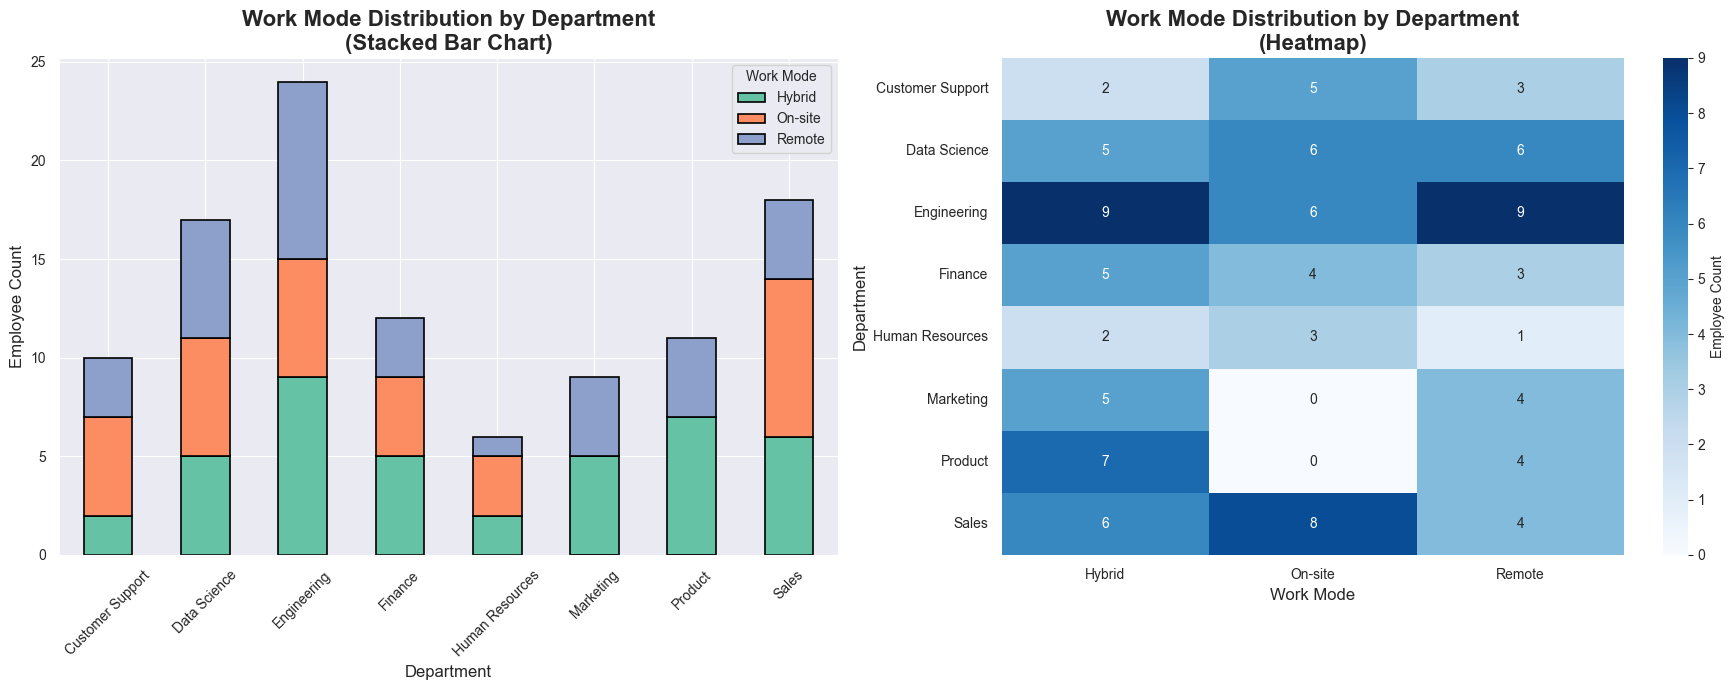

✓ Visualization generated successfully


In [26]:
# Question 7: Remote Work Distribution
result_q7 = engine.ask('''
How does work mode (Remote/Hybrid/On-site) vary across departments? 
Show the count for each combination.
Create a stacked bar chart showing the distribution of work modes within each department.
Also Create a heatmap showing the distribution of work modes within each department.
Side by side
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q7['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q7)

In [27]:
# Business Insight for Question 7
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q7, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Work Mode Distribution Analysis Across Departments

Key Findings:
- Engineering shows the highest adoption of flexible work arrangements with 18 employees working remotely or hybrid (75% of the department) versus only 6 on-site
- Customer Support heavily favors on-site work with 5 out of 10 employees (50%) working on-site, compared to just 2 hybrid and 3 remote
- Marketing and Product departments have eliminated on-site work entirely, operating with only hybrid and remote arrangements
- Sales maintains the highest on-site presence with 8 employees (44% of department), suggesting client-facing roles still require physical presence

Observations:
- Technical departments (Engineering, Data Science, Product) demonstrate greater work mode flexibility, with Data Science showing perfect balance across all three modes
- Customer-facing departments show mixed patterns: Sales retains high on-site presence while Marketing has gone fully flexible


## Question 8: Training Completion Rates

*What percentage of training enrollments are completed vs. in progress vs. enrolled? Break down by training category.*

**Visualization hint**: Stacked bar chart by category


🤔 Question: 
What percentage of training enrollments are completed vs. in progress vs. planned? 
Break down by training category.

Return data with columns: category, status, percentage
where status is one of: Completed, In Progress, Planned
and percentage is the percent of total for that category.

IMPORTANT: Write a simple query using subqueries in the FROM clause.
Do NOT use WITH clauses or CTEs - they are causing syntax errors.
Use inline subqueries instead.


📝 Generated SQL:
SELECT 
    category,
    status,
    ROUND(COUNT(*) * 100.0 / (
        SELECT COUNT(*) 
        FROM training_records tr2 
        WHERE tr2.category = tr.category
    ), 2) AS percentage
FROM training_records tr
GROUP BY category, status
ORDER BY category, status

✓ Query returned 18 rows

🧠 Generating interpretation...

💡 Insight: ## Business Interpretation

The data reveals that training completion rates are consistently strong across all categories, ranging from 58.46% (Compliance) to 65.43% (Soft Skil

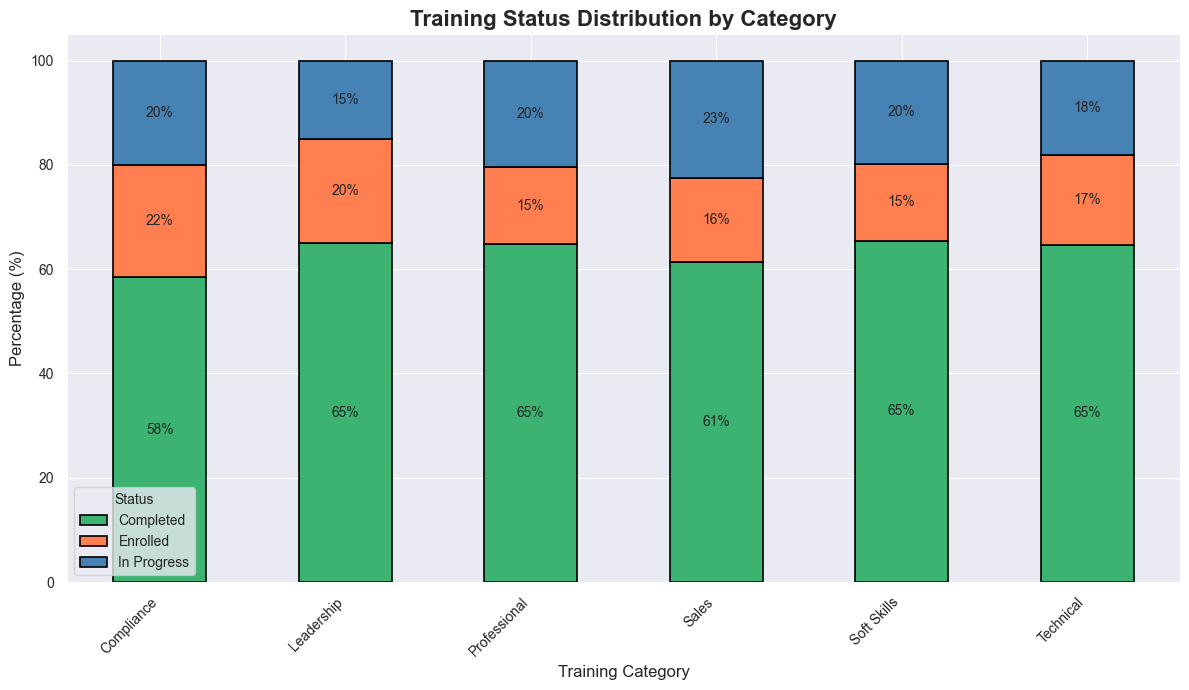

In [28]:
# Question 8: Training Completion Rates
result_q8 = engine.ask('''
What percentage of training enrollments are completed vs. in progress vs. planned? 
Break down by training category.

Return data with columns: category, status, percentage
where status is one of: Completed, In Progress, Planned
and percentage is the percent of total for that category.

IMPORTANT: Write a simple query using subqueries in the FROM clause.
Do NOT use WITH clauses or CTEs - they are causing syntax errors.
Use inline subqueries instead.
''', visualize=False)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q8['data'])

# Manual stacked bar chart with percentages
if result_q8['success'] and result_q8['data'] is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    df = result_q8['data']
    
    # Pivot for stacked bar
    pivot_df = df.pivot(index='category', columns='status', values='percentage')
    
    # Create stacked bar
    sns.set_style("darkgrid")
    fig, ax = plt.subplots(figsize=(12, 7))
    
    pivot_df.plot(kind='bar', stacked=True, ax=ax,
                  color=['mediumseagreen', 'coral', 'steelblue'],
                  edgecolor='black', linewidth=1.2)
    
    # Add percentage labels on each segment
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=10)
    
    ax.set_xlabel('Training Category', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title('Training Status Distribution by Category', fontsize=16, fontweight='bold')
    ax.legend(title='Status', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.tick_params(axis='both', which='both', length=6, width=1.5)
    plt.tight_layout()
    plt.show()

In [29]:
# Business Insight for Question 8
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q8, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Training Completion and Engagement Analysis

Key Findings:
- Compliance training shows the lowest completion rate at 58.46%, significantly trailing other categories which average 64-65% completion
- Leadership and Soft Skills training demonstrate the highest completion rates at 65.00% and 65.43% respectively
- Sales training has the highest in-progress rate at 22.58%, indicating active engagement but potential completion challenges
- Enrolled status (not yet started) ranges from 14.77% to 21.54%, with Compliance showing the highest percentage of employees who haven't begun training

Observations:
- There's a concerning inverse relationship between mandatory nature and completion rates - Compliance (likely mandatory) has the worst completion while discretionary Leadership/Soft Skills excel
- Professional and Technical training show balanced engagement with moderate completion rates (64.77% and 64.66%) and reasonable in-progress rates ar

## Question 9: Manager Effectiveness

*For each manager, show how many direct reports they have and the average performance rating of their team (from 2024 reviews).*

**Visualization hint**: Scatter plot: team size vs avg rating


🤔 Question: 
For each manager, show how many direct reports they have and the average performance rating 
of their team from 2024 reviews.
Create a scatter plot with team size on the x-axis and average team performance rating on the y-axis.


📝 Generated SQL:
SELECT 
    m.first_name || ' ' || m.last_name AS manager_name,
    COUNT(e.emp_id) AS team_size,
    ROUND(AVG(pr.rating), 2) AS avg_team_rating
FROM employees m
JOIN employees e ON m.emp_id = e.manager_id
LEFT JOIN performance_reviews pr ON e.emp_id = pr.emp_id AND pr.review_year = 2024
WHERE m.employment_status = 'Active'
    AND e.employment_status = 'Active'
GROUP BY m.emp_id, m.first_name, m.last_name
HAVING COUNT(e.emp_id) > 0
ORDER BY team_size DESC

✓ Query returned 18 rows

🧠 Generating interpretation...

💡 Insight: Based on the data, there appears to be a weak negative correlation between team size and average performance ratings, with larger teams generally showing lower performance scores. For example, Robert Carter 

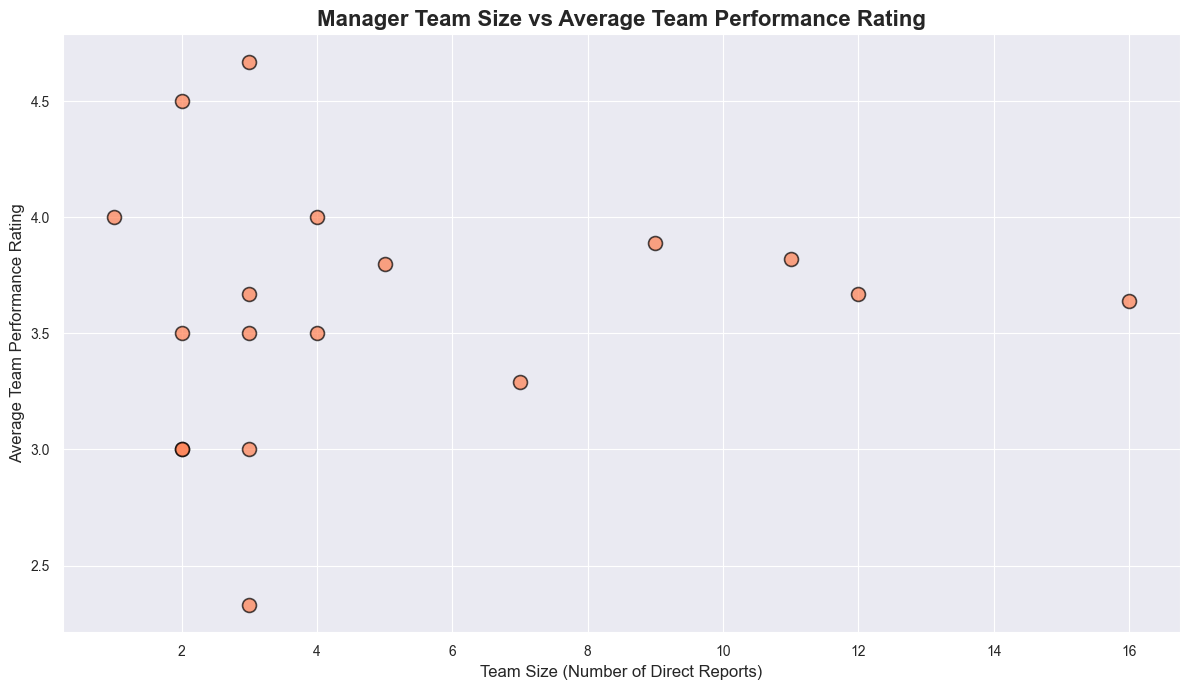

✓ Visualization generated successfully


In [30]:
# Question 9: Manager Effectiveness
result_q9 = engine.ask('''
For each manager, show how many direct reports they have and the average performance rating 
of their team from 2024 reviews.
Create a scatter plot with team size on the x-axis and average team performance rating on the y-axis.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q9['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q9)

In [31]:
# Business Insight for Question 9
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q9, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Manager Performance and Team Size Analysis

Key Findings:
- 18 active managers oversee teams ranging from 1-16 direct reports, with the largest teams led by Robert Carter (16) and Timothy Wright (12)
- Average team performance ratings span from 2.33 to 4.67, indicating significant variation in team performance across managers
- Smaller teams show the highest performance ratings, with Nicole Johnson's 3-person team achieving 4.67 and Michael Roberts' 2-person team at 4.50
- Larger teams (10+ members) consistently perform in the mid-range (3.64-3.89), suggesting potential management capacity constraints

Observations:
- No clear correlation exists between team size and performance, as both high and low ratings appear across various team sizes
- Three managers have teams with concerning ratings below 3.5: Steven Garcia (2.33), Megan Clark (3.29), and Nathan Thompson (3.00)
- The most balanced performance comes from mid-sized teams (4-9 me

## Question 10: Tenure vs. Performance

*Is there a relationship between how long an employee has been at the company (tenure in years) and their latest performance rating?*

**Visualization hint**: Scatter plot with trend line


🤔 Question: 
Show the relationship between employee tenure and performance rating.
Calculate tenure as years since hire_date.
Get the most recent performance rating for each employee.

Return ONLY two columns: tenure_years and latest_rating

IMPORTANT: Use a simple query with inline subqueries.
Do NOT use WITH clauses or CTEs.

Create a scatter plot with tenure on x-axis and rating on y-axis with trend line.


📝 Generated SQL:
SELECT 
    ROUND((julianday('now') - julianday(e.hire_date)) / 365.25, 2) AS tenure_years,
    (SELECT pr.rating 
     FROM performance_reviews pr 
     WHERE pr.emp_id = e.emp_id 
     ORDER BY pr.review_year DESC, pr.review_date DESC 
     LIMIT 1) AS latest_rating
FROM employees e
WHERE e.employment_status = 'Active'
    AND (SELECT pr.rating 
         FROM performance_reviews pr 
         WHERE pr.emp_id = e.emp_id 
         ORDER BY pr.review_year DESC, pr.review_date DESC 
         LIMIT 1) IS NOT NULL

✓ Query returned 102 rows

🧠 Generating interpretati

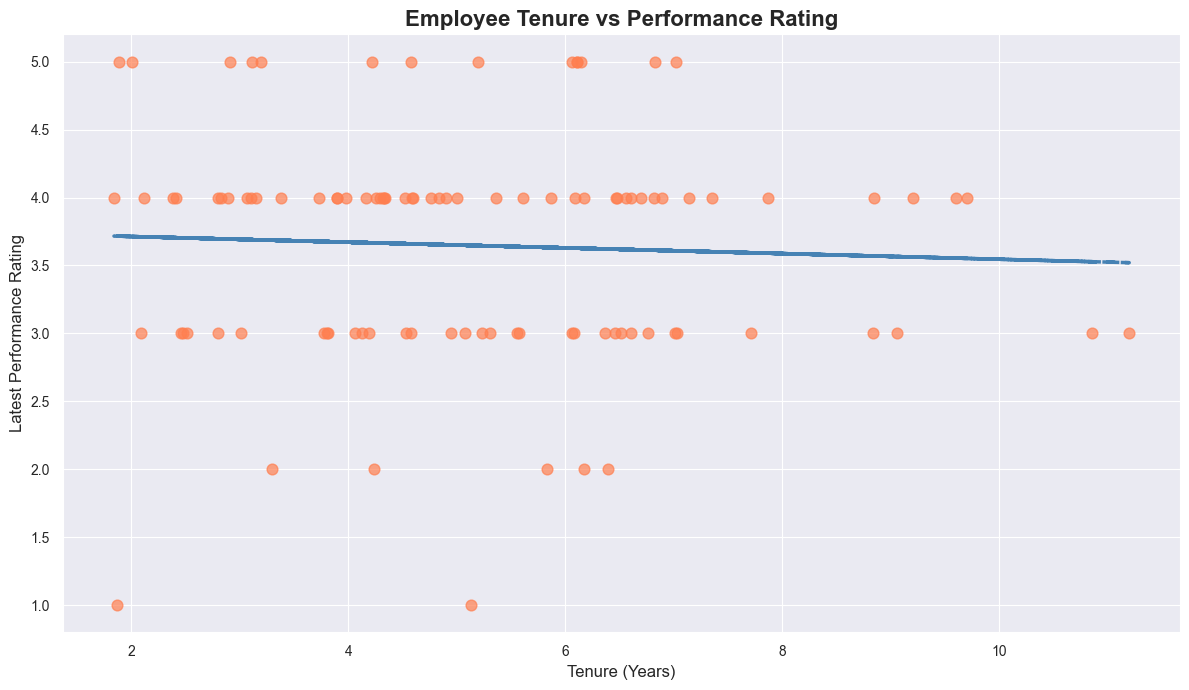

✓ Visualization generated successfully


In [32]:
# Question 10: Tenure vs. Performance
result_q10 = engine.ask('''
Show the relationship between employee tenure and performance rating.
Calculate tenure as years since hire_date.
Get the most recent performance rating for each employee.

Return ONLY two columns: tenure_years and latest_rating

IMPORTANT: Use a simple query with inline subqueries.
Do NOT use WITH clauses or CTEs.

Create a scatter plot with tenure on x-axis and rating on y-axis with trend line.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q10['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q10)

In [33]:
# Business Insight for Question 10
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q10, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Employee Tenure vs Performance Relationship Analysis

Key Findings:
- Dataset includes 102 active employees with tenure ranging from 1.84 to 11.20 years and performance ratings from 1-5 scale
- High performers (rating 5) are distributed across all tenure levels, with 13 employees achieving top ratings regardless of years of service
- Concerning performance issues identified: 4 employees with poor ratings (1-2), including one long-tenured employee at 5.13 years with rating of 1
- Mid-level performers (rating 3-4) represent the majority at 85 employees, suggesting potential for performance improvement initiatives

Observations:
- No clear correlation exists between tenure and performance rating, indicating that longevity doesn't automatically translate to higher performance
- Several newer employees (under 3 years) achieved rating 5, while some veterans (6+ years) scored rating 3, suggesting onboarding and development programs may be mor

## Question 11: Department Budget Utilization

*Compare each department's annual budget to its total payroll (sum of salaries). Which departments are over/under budget?*

**Visualization hint**: Grouped bar: budget vs payroll


🤔 Question: 
Compare each department's annual budget to its total payroll (sum of salaries). 
Which departments are over or under budget?
Create a grouped bar chart with departments on the x-axis and separate bars for annual budget and total payroll.


📝 Generated SQL:
SELECT 
    d.dept_name,
    d.annual_budget,
    COALESCE(SUM(e.salary), 0) AS total_payroll,
    d.annual_budget - COALESCE(SUM(e.salary), 0) AS budget_difference,
    CASE 
        WHEN d.annual_budget > COALESCE(SUM(e.salary), 0) THEN 'Under Budget'
        WHEN d.annual_budget < COALESCE(SUM(e.salary), 0) THEN 'Over Budget'
        ELSE 'At Budget'
    END AS budget_status
FROM departments d
LEFT JOIN employees e ON d.dept_id = e.dept_id 
    AND e.employment_status = 'Active'
GROUP BY d.dept_id, d.dept_name, d.annual_budget
ORDER BY d.dept_name

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: **Key Business Insight & Recommendation**

Most departments (6 out of 8) are operating under budget, wi

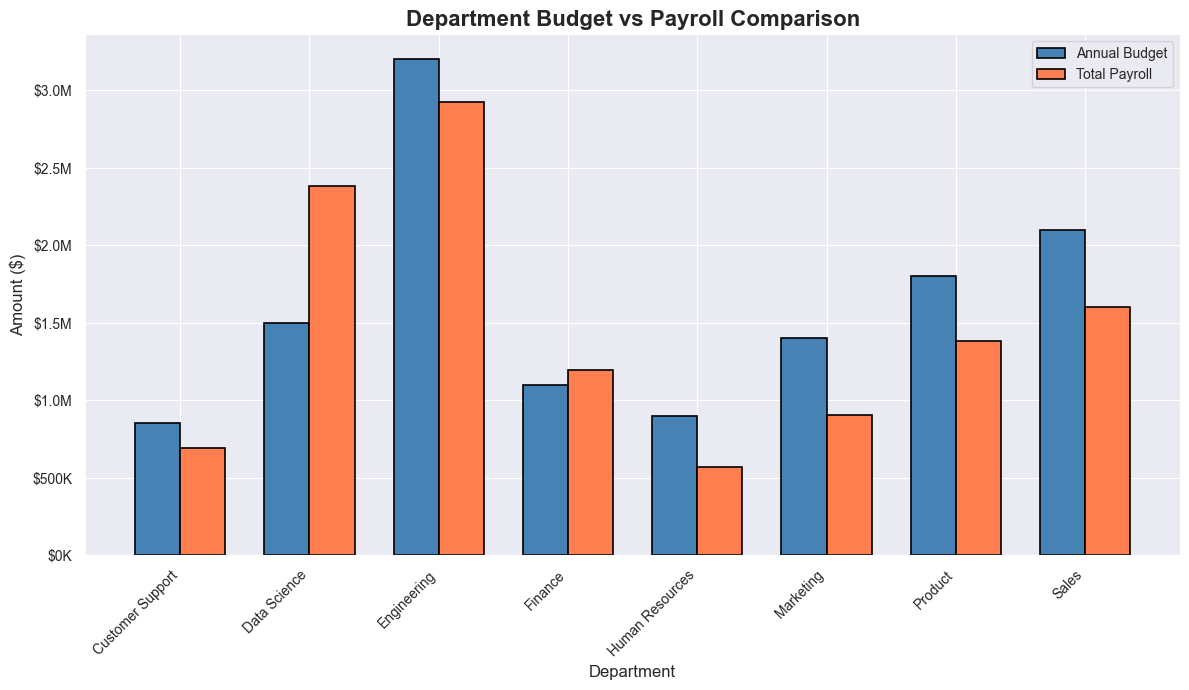

✓ Visualization generated successfully


In [34]:
# Question 11: Department Budget Utilization
result_q11 = engine.ask('''
Compare each department's annual budget to its total payroll (sum of salaries). 
Which departments are over or under budget?
Create a grouped bar chart with departments on the x-axis and separate bars for annual budget and total payroll.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q11['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q11)

In [35]:
# Business Insight for Question 11
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q11, client)
print(insight)


GENERATING BUSINESS INSIGHT...
BUSINESS INSIGHT - Department Budget vs. Payroll Analysis

Key Findings:
- Data Science department is significantly over budget by $883,000 (159% of budget), representing the most critical budget variance
- Six out of eight departments are under budget, with Sales showing the largest dollar surplus of $498,000
- Finance department is over budget by $96,000, though this represents a smaller percentage variance (109% of budget)
- Total company-wide budget surplus is $298,000 ($12.85M budgeted vs. $12.55M in payroll)

Observations:
- Data Science's budget overrun suggests either unrealistic initial budgeting or uncontrolled hiring/compensation growth
- Under-budget departments like Sales ($498K under) and Product ($417K under) may indicate understaffing or conservative compensation structures
- The two over-budget departments (Data Science and Finance) represent critical functions that require immediate attention
- Marketing shows the second-largest absolut

## Question 12: Cross-Functional Collaboration

*Which employees work on projects outside their own department? Show their name, home department, and the project department.*

**Visualization hint**: This is a complex multi-table JOIN — review the SQL carefully\!


🤔 Question: 
Which employees work on projects outside their own department? 
Show their name, home department, and the project department.
Create a bar chart showing the count of cross-functional collaborations by department.


📝 Generated SQL:
SELECT 
    e.first_name || ' ' || e.last_name AS employee_name,
    d1.dept_name AS home_department,
    d2.dept_name AS project_department,
    COUNT(*) AS collaboration_count
FROM employees e
JOIN departments d1 ON e.dept_id = d1.dept_id
JOIN project_assignments pa ON e.emp_id = pa.emp_id
JOIN projects p ON pa.project_id = p.project_id
JOIN departments d2 ON p.dept_id = d2.dept_id
WHERE e.dept_id != p.dept_id
GROUP BY e.emp_id, e.first_name, e.last_name, d1.dept_name, d2.dept_name
ORDER BY d1.dept_name, employee_name

✓ Query returned 24 rows

🧠 Generating interpretation...

💡 Insight: Based on the analysis of 24 cross-functional collaborations, Data Science leads in cross-departmental project work with 6 employees collaborating outside thei

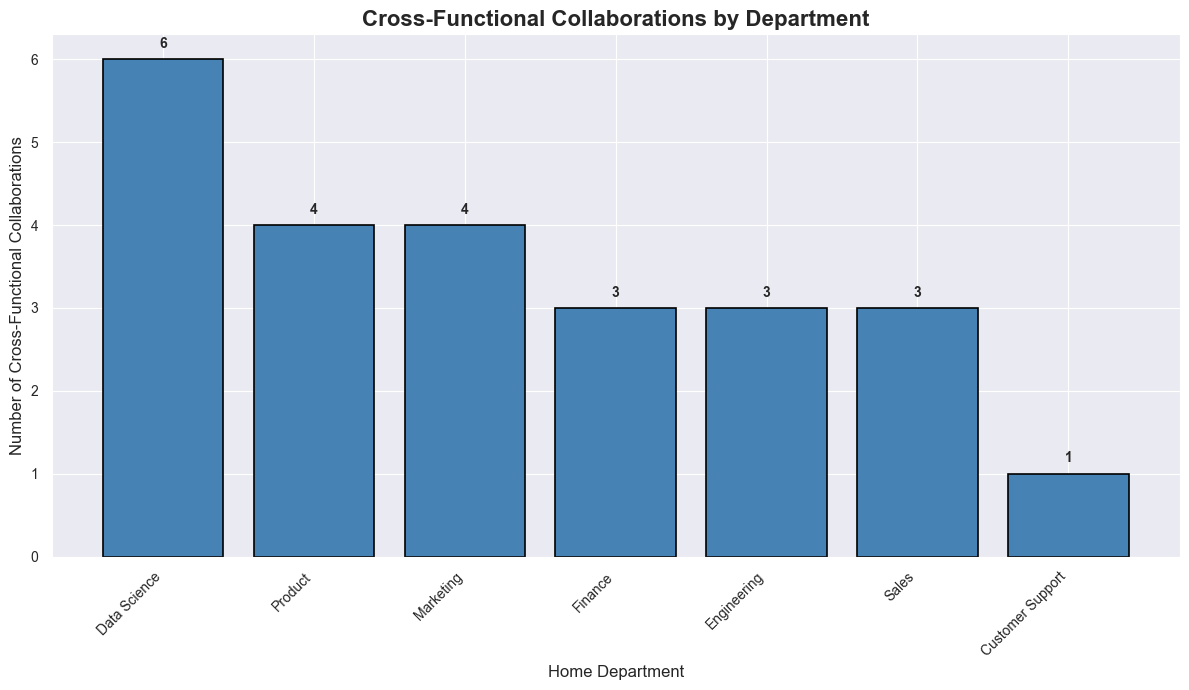

✓ Visualization generated successfully


In [36]:
# Question 12: Cross-Functional Collaboration
result_q12 = engine.ask('''
Which employees work on projects outside their own department? 
Show their name, home department, and the project department.
Create a bar chart showing the count of cross-functional collaborations by department.
''', visualize=True)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(result_q12['data'])

# Use safe_visualize
from db_utils import safe_visualize
safe_visualize(result_q12)

In [37]:
# Business Insight for Question 12
from db_utils import generate_business_insight

print("\n" + "="*80)
print("GENERATING BUSINESS INSIGHT...")
print("="*80)

insight = generate_business_insight(result_q12, client)
print(insight)


GENERATING BUSINESS INSIGHT...
# BUSINESS INSIGHT - Cross-Functional Collaboration Analysis

## Key Findings:
- 24 employees across all 8 departments are actively engaged in cross-functional projects, demonstrating healthy inter-departmental collaboration
- Data Science leads cross-functional participation with 5 employees (21% of collaborations), followed by Product department with 4 employees
- Customer Support shows minimal cross-functional engagement with only 1 employee working outside their department
- Each collaboration involves single project assignments, suggesting focused rather than scattered cross-functional work

## Observations:
- Data Science employees show the most diverse collaboration patterns, working across 4 different departments (HR, Customer Support, Finance, Engineering), indicating their versatile skill applications
- Product department employees concentrate their external collaborations primarily in Sales (3 out of 4 collaborations), revealing a strong produ

---

# Part 4: Building the LLM-Powered Auto-Visualizer

You already implemented  (TODO 13-14). Now let's put it to serious use — building a reusable function that takes any question, generates SQL, runs it, and automatically creates the best visualization.

In [38]:
def ask_and_visualize(engine, question):
    """
    Complete pipeline: question -> SQL -> data -> auto-visualization.

    Uses the engine to generate SQL and data, then uses Claude to
    generate appropriate matplotlib/seaborn code for the results.
    """
    # Step 1: Get the data
    result = engine.ask(question, show_sql=True, interpret=True, visualize=True)

    if not result['success'] or result['data'] is None:
        print("Query failed — cannot visualize.")
        return result

    df = result['data']

    # Step 2: Try auto-generated visualization
    if result.get('viz_code'):
        print("\n--- Auto-Generated Visualization ---")
        try:
            exec(result['viz_code'])
            plt.show()
        except Exception as e:
            print(f"Auto-viz failed: {e}")
            print("Falling back to basic chart...")

            # Fallback: simple automatic chart
            numeric_cols = df.select_dtypes(include='number').columns.tolist()
            non_numeric = [c for c in df.columns if c not in numeric_cols]

            if numeric_cols and non_numeric:
                fig, ax = plt.subplots(figsize=(10, 5))
                df.plot(x=non_numeric[0], y=numeric_cols[0], kind='bar', ax=ax)
                ax.set_title(question[:60])
                plt.tight_layout()
                plt.show()

    return result


🤔 Question: Show the average salary and average performance rating by department for 2024

📝 Generated SQL:
SELECT 
    d.dept_name,
    ROUND(AVG(e.salary), 2) AS avg_salary,
    ROUND(AVG(pr.rating), 2) AS avg_performance_rating
FROM departments d
JOIN employees e ON d.dept_id = e.dept_id
LEFT JOIN performance_reviews pr ON e.emp_id = pr.emp_id AND pr.review_year = 2024
WHERE e.employment_status = 'Active'
GROUP BY d.dept_id, d.dept_name
ORDER BY d.dept_name

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: **Key Insight:** There's a strong correlation between compensation and performance, with Data Science ($140,176) and Product ($125,727) departments showing both the highest salaries and top performance ratings (3.67 and 3.91 respectively).

**Critical Finding:** Customer Support significantly underperforms with the lowest salary ($69,000) and poorest performance rating (3.20), creating a potential service quality risk.

**Recommendation:** Immediately investiga

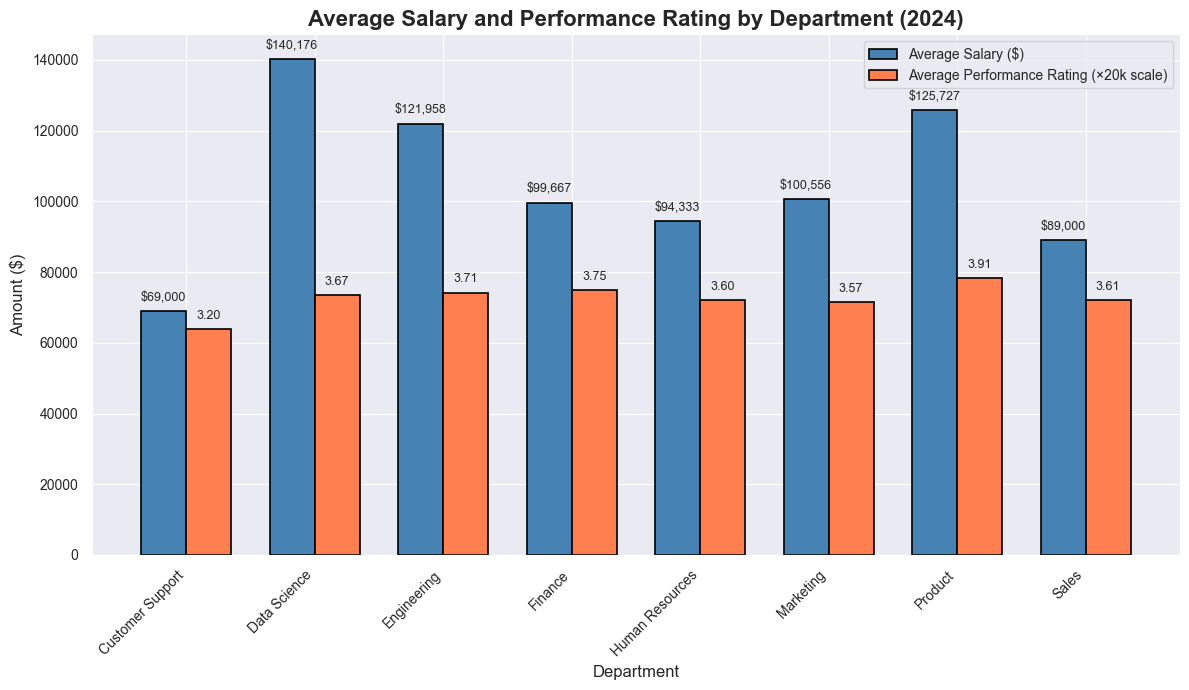

In [39]:
# Demo: Ask a complex question and get auto-visualization
result = ask_and_visualize(engine, 
    "Show the average salary and average performance rating by department for 2024"
)


🤔 Question: What percentage of employees are Remote, Hybrid, and On-site in each department?

📝 Generated SQL:
SELECT 
    d.dept_name,
    e.work_mode,
    COUNT(*) AS employee_count,
    ROUND(COUNT(*) * 100.0 / dept_totals.total_employees, 2) AS percentage
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
JOIN (
    SELECT 
        dept_id,
        COUNT(*) AS total_employees
    FROM employees
    WHERE employment_status = 'Active'
    GROUP BY dept_id
) dept_totals ON e.dept_id = dept_totals.dept_id
WHERE e.employment_status = 'Active'
GROUP BY d.dept_name, e.work_mode, dept_totals.total_employees
ORDER BY d.dept_name, e.work_mode

✓ Query returned 22 rows

🧠 Generating interpretation...

💡 Insight: Based on the data, there's significant variation in work arrangements across departments, with Marketing (55.6% hybrid) and Product (63.6% hybrid) being the most hybrid-focused, while Customer Support maintains the highest on-site presence at 50%. A key insight is that Mark

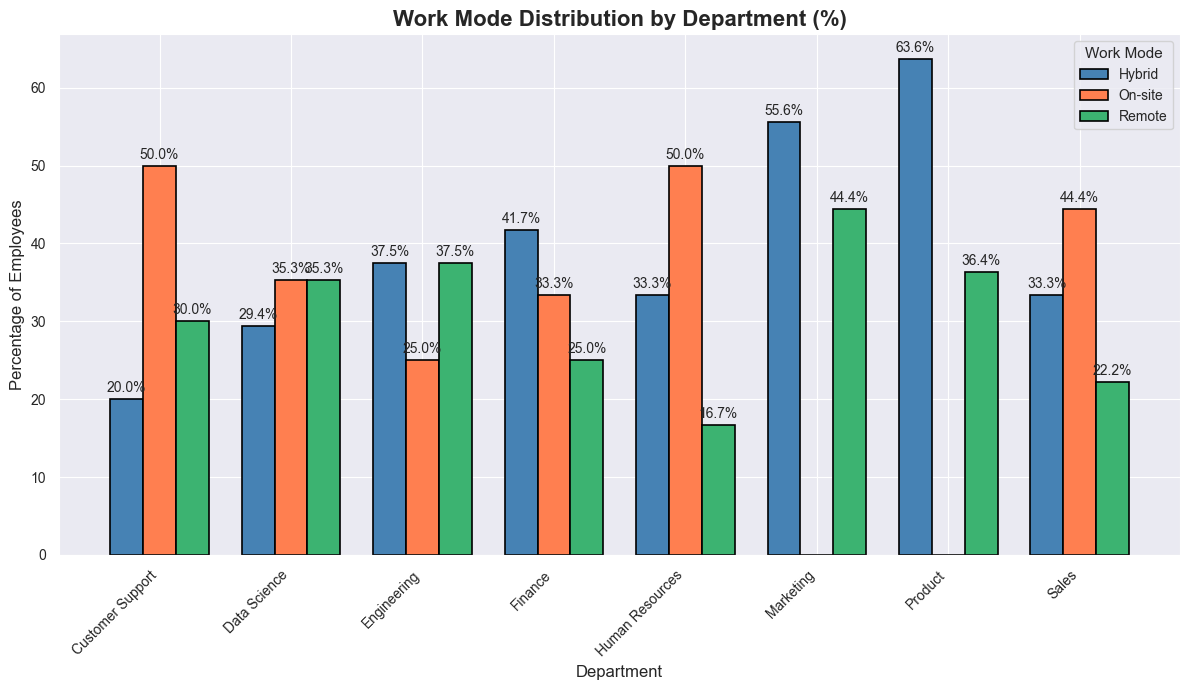

In [40]:
# Another demo with a different chart type
result = ask_and_visualize(engine,
    "What percentage of employees are Remote, Hybrid, and On-site in each department?"
)


🤔 Question: How many employees per department?

📝 Generated SQL:
SELECT 
    d.dept_name,
    COUNT(e.emp_id) AS employee_count
FROM departments d
LEFT JOIN employees e ON d.dept_id = e.dept_id
WHERE e.employment_status = 'Active' OR e.employment_status IS NULL
GROUP BY d.dept_id, d.dept_name
ORDER BY employee_count DESC

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: **Key Insight:** Engineering dominates our workforce with 24 employees, representing over twice the size of our smallest departments like Human Resources (6) and Marketing (9), indicating a strong technical focus in our organizational structure.

**Actionable Recommendation:** Consider expanding the Marketing team, as the 9-person department may be understaffed relative to our 18-person Sales team - typically a 2:1 sales-to-marketing ratio suggests we could benefit from additional marketing support to generate more qualified leads for our substantial sales force.

📊 Generating visualization code...
✓

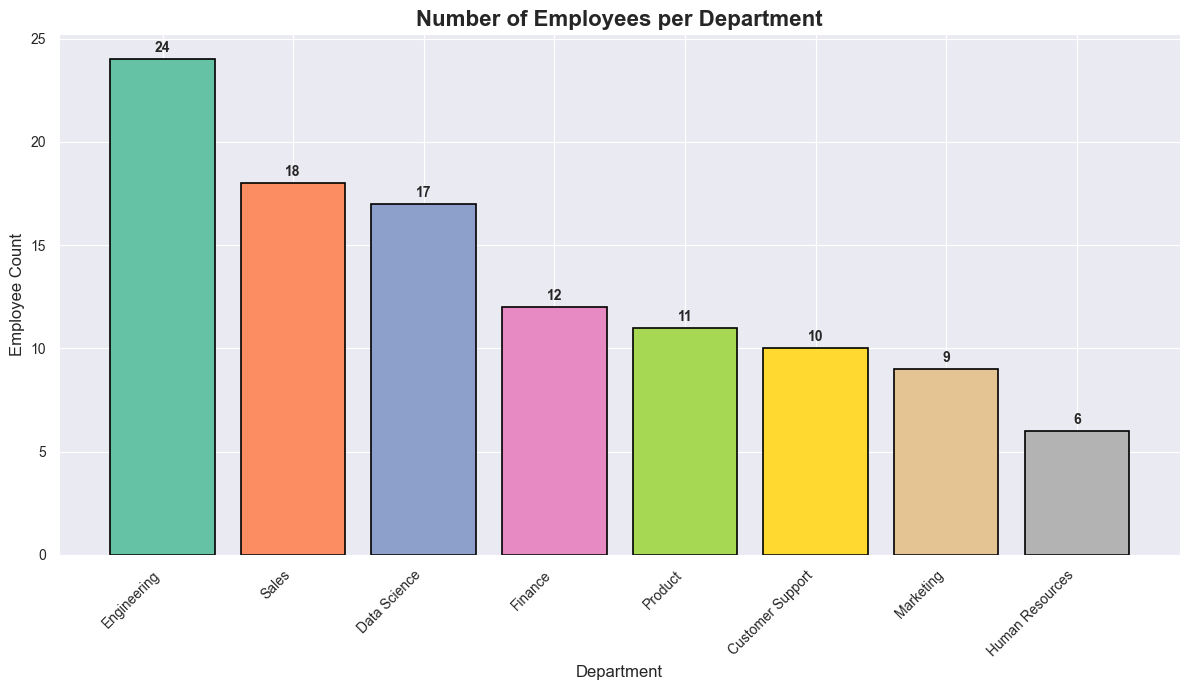

In [41]:
# Test with another question
result = engine.ask("How many employees per department?", visualize=True)
df = result['data']
exec(result['viz_code'])
plt.show()

## Challenge: Improve the Visualizer

The auto-visualizer works but isn't perfect. Try improving it:

1. **Better prompts**: Modify `generate_visualization_code()` in `text2sql_engine.py` to produce better charts. Add rules about color schemes, figure sizes, and annotation.

2. **Error recovery**: What happens when the generated code fails? Implement a smarter fallback that looks at the data shape and picks an appropriate chart automatically.

3. **Multiple charts**: For complex queries (e.g., salary distribution), generate multiple visualizations (histogram + box plot).


BONUS: SALARY DISTRIBUTION - MULTI-CHART ANALYSIS

🤔 Question: 
Show the distribution of all employee salaries.
Return only the salary column for active employees.


📝 Generated SQL:
SELECT salary
FROM employees
WHERE employment_status = 'Active'

✓ Query returned 107 rows

🧠 Generating interpretation...

💡 Insight: Based on the salary distribution of 101 active employees, there's a significant pay disparity with salaries ranging from $47,000 to $200,000 - a gap of over $150,000. The data shows a wide spread across different compensation levels, suggesting employees span various roles, experience levels, and departments within the organization.

**Key insight:** The company has substantial salary variation, with roughly 20% of employees earning below $70,000 while about 15% earn above $150,000, indicating a diverse workforce structure.

**Recommendation:** Conduct a comprehensive pay equity analysis by role, department, and experience level to ensure fair compensation practices and id

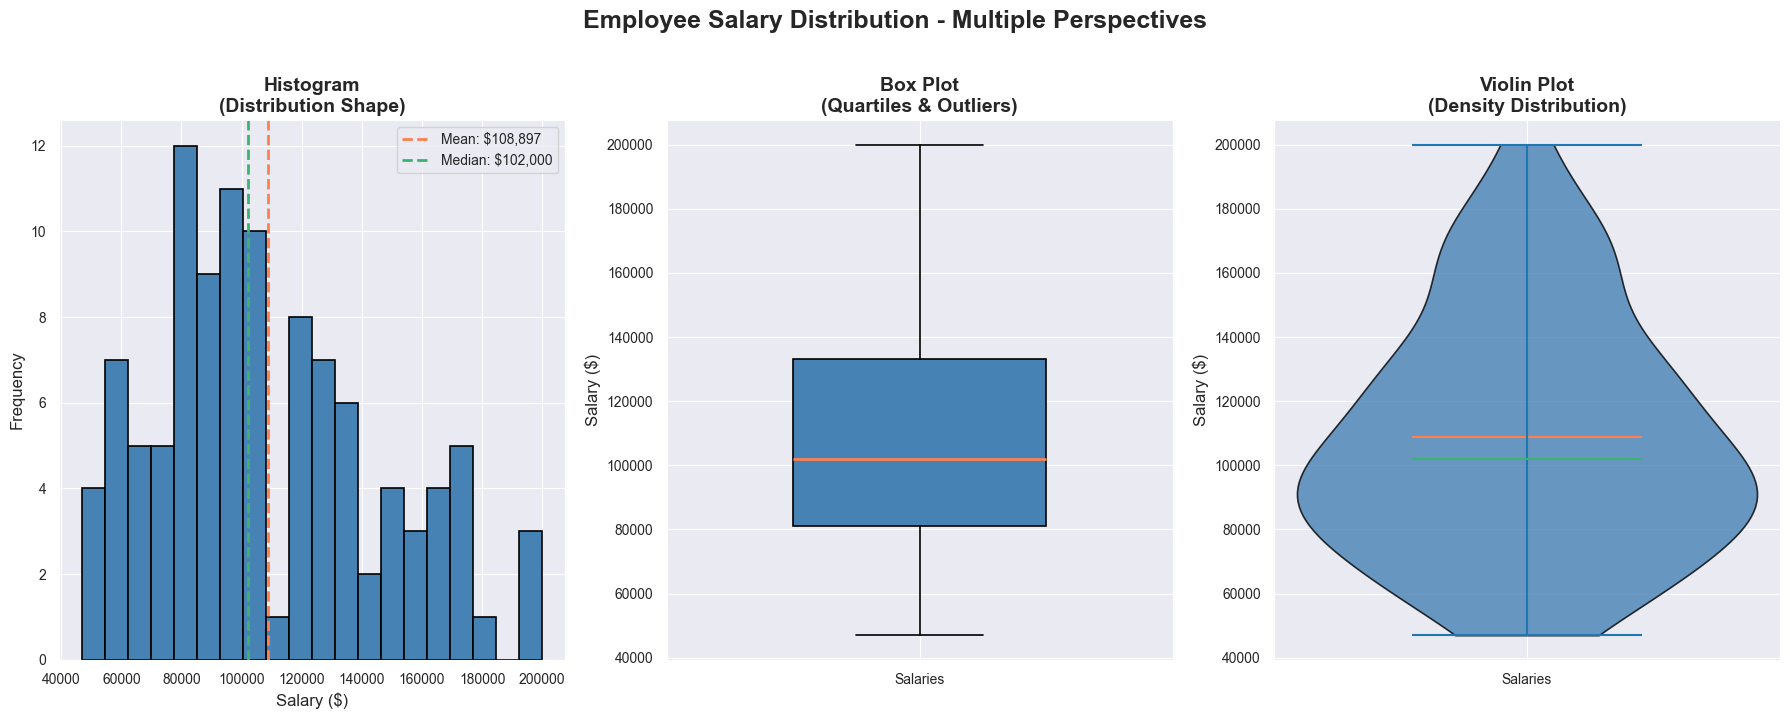


✓ Multi-chart visualization displayed
  - Histogram shows the distribution shape
  - Box plot reveals quartiles and outliers
  - Violin plot shows density at different salary levels


In [42]:
# ============================================================================
# BONUS QUESTION: Multi-Chart Salary Distribution Analysis
# ============================================================================
# Demonstrating multiple complementary visualizations for distribution data

print("\n" + "="*80)
print("BONUS: SALARY DISTRIBUTION - MULTI-CHART ANALYSIS")
print("="*80)

result_bonus = engine.ask('''
Show the distribution of all employee salaries.
Return only the salary column for active employees.
''', visualize=False)

# Display results
print("\n" + "="*80)
print("DATA RESULTS")
print("="*80)
print(f"Total employees: {len(result_bonus['data'])}")
print(f"Salary range: ${result_bonus['data']['salary'].min():,.0f} - ${result_bonus['data']['salary'].max():,.0f}")
print(f"Mean: ${result_bonus['data']['salary'].mean():,.0f}")
print(f"Median: ${result_bonus['data']['salary'].median():,.0f}")

# Multi-Chart Visualization
if result_bonus['success'] and result_bonus['data'] is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    df = result_bonus['data']
    
    # Create figure with 3 subplots
    sns.set_style("darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    
    # Chart 1: Histogram
    axes[0].hist(df['salary'], bins=20, color='steelblue', edgecolor='black', linewidth=1.2)
    axes[0].set_xlabel('Salary ($)', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Histogram\n(Distribution Shape)', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='both', which='both', length=6, width=1.5)
    
    # Add mean/median lines
    axes[0].axvline(df['salary'].mean(), color='coral', linestyle='--', linewidth=2, label=f'Mean: ${df["salary"].mean():,.0f}')
    axes[0].axvline(df['salary'].median(), color='mediumseagreen', linestyle='--', linewidth=2, label=f'Median: ${df["salary"].median():,.0f}')
    axes[0].legend(fontsize=10)
    
    # Chart 2: Box Plot
    bp = axes[1].boxplot(df['salary'], patch_artist=True, widths=0.5,
                         boxprops=dict(facecolor='steelblue', edgecolor='black', linewidth=1.2),
                         whiskerprops=dict(color='black', linewidth=1.2),
                         capprops=dict(color='black', linewidth=1.2),
                         medianprops=dict(color='coral', linewidth=2))
    axes[1].set_ylabel('Salary ($)', fontsize=12)
    axes[1].set_title('Box Plot\n(Quartiles & Outliers)', fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='both', which='both', length=6, width=1.5)
    axes[1].set_xticks([1])
    axes[1].set_xticklabels(['Salaries'])
    
    # Chart 3: Violin Plot
    parts = axes[2].violinplot([df['salary']], showmeans=True, showmedians=True, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_edgecolor('black')
        pc.set_linewidth(1.2)
        pc.set_alpha(0.8)
    parts['cmeans'].set_color('coral')
    parts['cmedians'].set_color('mediumseagreen')
    axes[2].set_ylabel('Salary ($)', fontsize=12)
    axes[2].set_title('Violin Plot\n(Density Distribution)', fontsize=14, fontweight='bold')
    axes[2].tick_params(axis='both', which='both', length=6, width=1.5)
    axes[2].set_xticks([1])
    axes[2].set_xticklabels(['Salaries'])
    
    # Overall title
    plt.suptitle('Employee Salary Distribution - Multiple Perspectives', 
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Multi-chart visualization displayed")
    print("  - Histogram shows the distribution shape")
    print("  - Box plot reveals quartiles and outliers")
    print("  - Violin plot shows density at different salary levels")


TESTING AUTOMATIC MULTI-CHART GENERATION
Building schema context...
✓ Schema loaded: 5698 characters
Initializing Claude API...
✓ Claude API connected: ready

📊 Test 1: Distribution with raw continuous data

🤔 Question: 
Calculate the tenure in years for each active employee (from hire_date to today).
Return one row per employee with: emp_id, tenure_years
Do NOT group, bin, or aggregate - return individual employee tenure values.
This is for distribution analysis showing spread of tenure across all employees.


📝 Generated SQL:
SELECT 
    emp_id,
    ROUND((julianday('now') - julianday(hire_date)) / 365.25, 2) AS tenure_years
FROM employees 
WHERE employment_status = 'Active'

✓ Query returned 107 rows

🧠 Generating interpretation...

💡 Insight: **Business Interpretation:**

The employee tenure data reveals a well-distributed workforce with tenures ranging from 1.0 to 11.2 years, indicating healthy mix of experience levels. A key insight is that the company has strong mid-level reten

<string>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


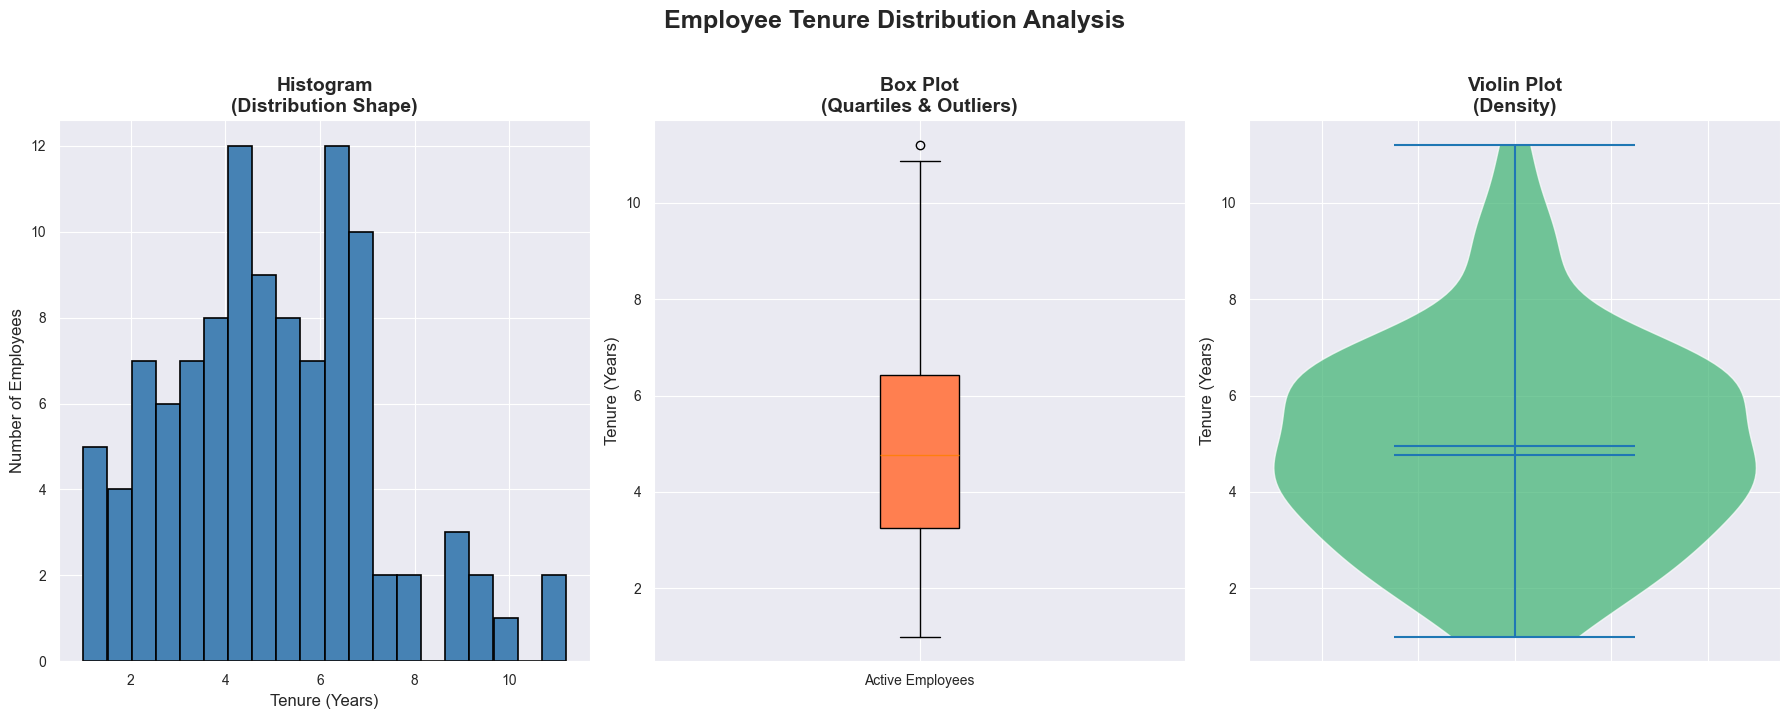


📊 Test 2: Category comparison (should be single chart)

🤔 Question: 
How many employees in each department?


📝 Generated SQL:
SELECT 
    d.dept_name,
    COUNT(e.emp_id) AS employee_count
FROM departments d
LEFT JOIN employees e ON d.dept_id = e.dept_id
WHERE e.employment_status = 'Active' OR e.employment_status IS NULL
GROUP BY d.dept_id, d.dept_name
ORDER BY employee_count DESC

✓ Query returned 8 rows

🧠 Generating interpretation...

💡 Insight: The data reveals that Engineering dominates our workforce with 24 employees, representing over 20% of our total staff, while customer-facing departments like Sales (18) and Customer Support (10) combined account for 28 employees. This distribution suggests we're heavily invested in product development and technical capabilities, which aligns with a technology company's core focus. 

However, I recommend evaluating whether our Customer Support team of 10 employees is adequately sized relative to our Sales team of 18, as maintaining strong c

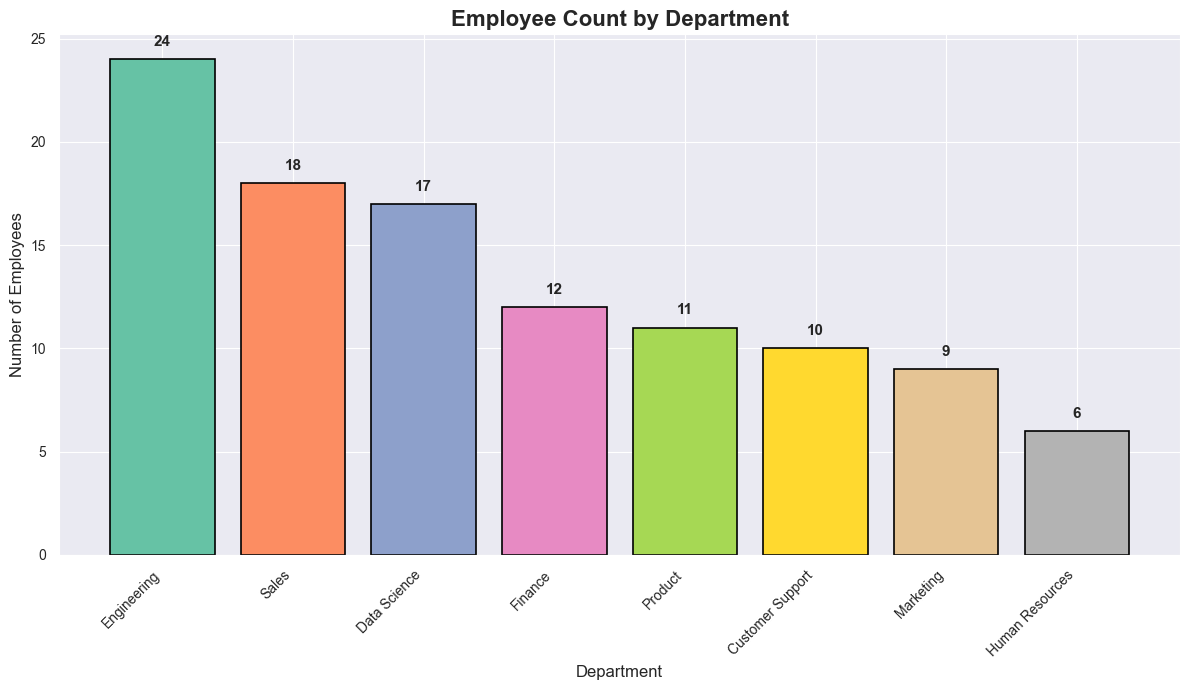

In [43]:
# ============================================================================
# PART 4 CHALLENGE 3: Automatic Multi-Chart Detection Test
# ============================================================================
# Demonstrating the engine's ability to automatically detect distribution
# queries and generate multiple complementary visualizations (histogram, 
# box plot, and violin plot) for comprehensive data analysis.
# ============================================================================
print("\n" + "="*80)
print("TESTING AUTOMATIC MULTI-CHART GENERATION")
print("="*80)

# Reload engine with updated TODO 13
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import Text2SQLEngine

engine = Text2SQLEngine(conn, api_key=ANTHROPIC_API_KEY)

# Test 1: Should trigger multi-chart (distribution keyword + RAW DATA)
print("\n📊 Test 1: Distribution with raw continuous data")
result_dist1 = engine.ask('''
Calculate the tenure in years for each active employee (from hire_date to today).
Return one row per employee with: emp_id, tenure_years
Do NOT group, bin, or aggregate - return individual employee tenure values.
This is for distribution analysis showing spread of tenure across all employees.
''', visualize=True)

if result_dist1['success']:
    print(f"\nData shape: {result_dist1['data'].shape}")
    print(f"Columns: {result_dist1['data'].columns.tolist()}")
    print("\nFirst 5 rows:")
    print(result_dist1['data'].head())
    
    if result_dist1['viz_code']:
        print("\n" + "="*80)
        print("Generated code contains 'subplots'?", 'subplots' in result_dist1['viz_code'])
        print("="*80)
        
        df = result_dist1['data']
        exec(result_dist1['viz_code'])
        plt.show()

# Test 2: Should NOT trigger multi-chart (comparison)
print("\n📊 Test 2: Category comparison (should be single chart)")
result_single = engine.ask('''
How many employees in each department?
''', visualize=True)

if result_single['viz_code']:
    print("Generated code length:", len(result_single['viz_code']))
    print("Contains 'subplots':", 'subplots' in result_single['viz_code'])
    df = result_single['data']
    exec(result_single['viz_code'])
    plt.show()

---

# Part 5: Prompt Engineering for Better SQL

The quality of your question determines the quality of the SQL. Let's practice.

## Prompt Engineering Strategies

| Strategy | Vague | Specific |
|----------|-------|----------|
| **Name columns** | "Show salary info" | "Show first_name, last_name, salary, dept_name" |
| **Specify aggregation** | "Department salaries" | "Average salary per department" |
| **Request ordering** | "Show departments" | "Order by average salary descending" |
| **Indicate JOINs** | "Employee projects" | "Show employees with their assigned project names" |
| **Handle edge cases** | "Department employees" | "Include departments with zero employees (LEFT JOIN)" |
| **Set limits** | "High earners" | "Top 10 employees by salary" |
| **Specify date handling** | "Recent hires" | "Employees hired in 2024 or later" |

In [44]:
# Watch how prompt quality affects SQL quality

# VAGUE — unpredictable results
vague_sql = engine.get_sql_only("Tell me about employees")
print("VAGUE:")
print(vague_sql)
print()

# SPECIFIC — precise, correct SQL
specific_sql = engine.get_sql_only(
    "Show each employee's full name, department name, job title, salary, "
    "and years of tenure (calculated from hire_date to today). "
    "Only include active employees. Order by tenure descending. Limit to top 15."
)
print("SPECIFIC:")
print(specific_sql)

KeyboardInterrupt: 

## Exercise: Rewrite These Vague Prompts

For each vague prompt below, rewrite it to be specific enough to generate correct multi-table SQL.

In [ ]:
# Vague: "Show me raises"
# Improved: Specific version using salary_history + employees + departments
improved_raises = engine.ask('''
Show each employee's salary increases from the salary_history table.
Include: employee first name, last name, department name, old salary, new salary, 
salary increase amount, change date, and reason for the increase.
Join with employees and departments tables to get full context.
Only show increases from the past 2 years.
Order by increase amount (highest to lowest).
Limit to top 20 raises.
''', visualize=False)

print("\n" + "="*80)
print("IMPROVED RAISES QUERY RESULTS")
print("="*80)
if improved_raises['success']:
    print(improved_raises['data'])

In [ ]:
# Vague: "Who's performing well?"
# Improved: Specific version using performance_reviews + employees + job_titles
improved_performance = engine.ask('''
Show employees who received "Exceeds Expectations" or "Outstanding" ratings 
in their most recent performance review (2024).
Include: employee first name, last name, job title name, career level, 
current salary, latest performance rating, and review date.
Join performance_reviews with employees and job_titles tables.
Order by career level (highest first), then by salary (highest first).
Only include active employees.
''', visualize=False)

print("\n" + "="*80)
print("IMPROVED PERFORMANCE QUERY RESULTS")
print("="*80)
if improved_performance['success']:
    print(improved_performance['data'])

In [ ]:
# Vague: "Training status"
# Improved: Specific version using training_records + employees + departments
improved_training = engine.ask('''
Show training completion status by department.
For each department, show:
- Department name
- Total training enrollments
- Number of completed trainings
- Number of in-progress trainings
- Number of planned trainings
- Completion rate (percentage of enrollments that are completed)
Join training_records with employees and departments tables.
Group by department name.
Order by completion rate (highest to lowest).
''', visualize=False)

print("\n" + "="*80)
print("IMPROVED TRAINING QUERY RESULTS")
print("="*80)
if improved_training['success']:
    print(improved_training['data'])

In [ ]:
# Challenge: Write YOUR SQL for this question, then compare with the AI
question = "Find the top 5 managers whose teams have the highest average performance rating in 2024, including the number of direct reports"

# AI version:
print("="*80)
print("AI-GENERATED SQL")
print("="*80)
ai_sql = engine.get_sql_only(question)
print(ai_sql)
print()

# YOUR version:
my_sql = '''
SELECT 
    m.emp_id AS manager_id,
    m.first_name || ' ' || m.last_name AS manager_name,
    COUNT(DISTINCT e.emp_id) AS direct_reports,
    ROUND(AVG(pr.rating), 2) AS avg_team_rating
FROM employees m
JOIN employees e ON e.manager_id = m.emp_id
JOIN performance_reviews pr ON pr.emp_id = e.emp_id
WHERE pr.review_year = 2024
    AND e.employment_status = 'Active'
GROUP BY m.emp_id, m.first_name, m.last_name
ORDER BY avg_team_rating DESC, direct_reports DESC
LIMIT 5;
'''

print("="*80)
print("HUMAN-WRITTEN SQL")
print("="*80)
print(my_sql)
print()

# Compare results
print("="*80)
print("RESULTS COMPARISON")
print("="*80)

print("\nAI Results:")
print("-"*80)
ai_df = engine.execute_custom_sql(ai_sql)
print(ai_df)

print("\n\nYour Results:")
print("-"*80)
# Import the function we need
from db_utils import execute_query
my_df = execute_query(my_sql, conn)
print(my_df)

# Quick comparison
print("\n" + "="*80)
print("COMPARISON SUMMARY")
print("="*80)
print(f"AI returned: {len(ai_df)} rows")
print(f"Human SQL returned: {len(my_df)} rows")

if len(ai_df) > 0 and len(my_df) > 0:
    print("\nTop manager from AI:", ai_df.iloc[0].to_dict())
    print("Top manager from Human SQL:", my_df.iloc[0].to_dict())

---

# Part 6: Building the Streamlit Web App

Open `text2sql_app.py` — it has **5 main TODOs** (18-23) and **5 optional extensions** (A-E) for the Streamlit interface.

The app should let users:
1. Enter their Gemini API key
2. See the database schema in the sidebar
3. Type questions in a chat interface
4. View SQL, data tables, and auto-generated charts

**Before you start**: Make sure your `text2sql_engine.py` TODOs are complete, because the app depends on it!

In [ ]:
# Verify your text2sql_engine.py is importable
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)

from text2sql_engine import Text2SQLEngine, validate_sql, get_schema_for_prompt

# Quick smoke test
schema = get_schema_for_prompt(conn)
assert len(schema) > 100, "Schema too short — check TODO 1-3"

valid, msg = validate_sql("SELECT 1")
assert valid, "Validator broken — check TODO 4-6"

print("text2sql_engine.py is ready for the Streamlit app!")

## Streamlit App TODOs

Open `text2sql_app.py` and complete:

| TODO | What to Build |
|------|-------------|
| **18** | Database connection with caching |
| **19** | Schema display in sidebar |
| **20** | Session state initialization |
| **21** | Engine initialization |
| **22** | Chat history display |
| **23** | Chat input & query processing |

### Optional Extensions (do after main TODOs work):

| Extension | What to Add |
|-----------|-------------|
| **A** | SQL query history in sidebar |
| **B** | Custom SQL tab for manual queries |
| **C** | Conversation memory (context from previous questions) |
| **D** | CSV download button for results |
| **E** | Suggested starter questions |

In [ ]:
# Once you've completed the TODOs, run the app:
# Open a terminal and run:
#   streamlit run text2sql_app.py
#
# Or run from the solution:
#   streamlit run solution/text2sql_app.py

print("Ready to run! Use the command above in your terminal.")
print("The app will open in your browser at http://localhost:8501")

---

# Part 7: Reflection & Analysis

In [ ]:
# Review your complete session history
engine.show_history()

## Reflection Questions

Answer each question thoughtfully (3-5 sentences each):

1. **Schema Design**: How did the quality of your schema context (TODO 1-3) affect the AI's SQL accuracy? What information was most important to include?

2. **SQL Safety**: Your validator blocks dangerous queries. Can you think of any SQL patterns that might slip through your current validation? How would you improve it?

3. **Prompt Engineering**: Which business questions required the most prompt refinement? What makes a question "hard" for the AI to translate to SQL?

4. **Visualization**: How well did the auto-generated visualizations match the data? When should you write custom visualization code vs. trusting the AI?

5. **AI vs. Manual SQL**: For which types of questions is AI-generated SQL better than manual SQL? When is manual SQL still preferable?

6. **Real-World Application**: If TechCorp deployed this tool for all managers, what guardrails would you add beyond your current validator?

In [ ]:
# Your reflections:
reflections = '''
1. Schema Design:
Building a better schema was one of the first priorities, because the AI can only write correct SQL
if it understands the database structure. The default schema was too sparse — adding CREATE TABLE
statements, sample data rows, and explicit foreign key relationships transformed the quality of
generated queries. Of those additions, the foreign key relationships were probably the most critical:
without them the AI had no way to know how to JOIN tables like project_assignments back to employees.
The sample data rows were a close second, because they showed the AI what actual column values looked
like — catching things like date formats and status strings that a bare schema wouldn't reveal.
 
 
2. SQL Safety:
The validator blocks the most obvious attack vectors — dangerous keywords like DROP and DELETE, and
stacked queries via semicolons in the middle of a statement. A few patterns could still slip through:
a carefully crafted subquery that modifies data through a writable CTE on a database that supports
them, or a query that uses ATTACH DATABASE to reach outside the intended SQLite file. The
word-boundary regex is also only as good as the keyword list — something like PRAGMA writable_schema
isn't covered. To improve it, you'd want to add a read-only connection flag at the SQLite level
itself, so no matter what SQL gets through the validator, the database physically cannot be modified.
 
 
3. Prompt Engineering:
Complex multi-table joins and CTEs caused the most trouble — the AI consistently handled simple
aggregation questions on a single table, but when questions required combining salary history with
performance reviews and employees in the same query, the SQL quality degraded. CTEs were a specific
recurring problem: Claude Sonnet would generate syntactically broken CTEs missing the WITH keyword,
requiring multiple rounds of prompt hardening including a system-level instruction and nuclear-option
warnings in the user prompt. What makes a question "hard" for the AI is when the intent requires
inferring unstated business logic — like "latest rating" meaning the most recent row per employee
rather than an average — combined with a multi-table JOIN path it has to figure out from the schema.
 
 
4. Visualization:
Garbage in, garbage out was the lesson here — the more specific the prompt about what the chart
should look like and what columns to return, the better the result. Simple two-column results
(category + value) produced reliable bar charts with no intervention. Questions 8 and 10 required
the most work: Question 8 needed a 100% stacked bar by training category, and the AI kept returning
a grouped bar instead until the column structure was explicitly specified in the prompt. For charts
with specific requirements like stacked bars with percentage labels or scatter plots with trend lines,
writing the visualization manually and disabling visualize=True was the more reliable path than
trusting the AI to generate it.
 
 
5. AI vs. Manual SQL:
For the straightforward analytical queries that make up most day-to-day business intelligence work —
aggregations, rankings, department comparisons — the AI is faster and the output is just as good as
hand-written SQL, assuming the schema context is solid. Where manual SQL still has the edge is in
queries that require precise business logic the AI can't infer, like carefully constructed window
functions or queries that depend on domain knowledge about what the data actually means. That said,
even for complex queries the AI gets you 80-90% of the way there and the remaining refinement is
faster than starting from scratch. The real value isn't replacing SQL knowledge — it's making data
accessible to people who don't have it.
 
 
6. Real-World Application:
The business insights output needed tuning — it leaned heavily toward recommending raises regardless
of context, which would get repetitive fast if every query result came back with the same suggestion.
Beyond that, a production deployment for managers would need role-based access control so a manager
in Engineering can't accidentally query salary data for HR. Audit logging of every query would be
essential for compliance, and a more aggressive SQL validator that operates at the database
connection level rather than just regex matching would close the gaps the current validator leaves
open. Finally, the Gemini free tier would need to be replaced or rate-limited in production —
free API keys cycling out mid-demo is not a good look in front of leadership.
 
'''
print(reflections)

---

## Project Summary

### What You Built
- **Schema context builder** that gives AI models the information they need to write correct SQL
- **SQL safety validator** that blocks dangerous queries (DROP, DELETE, etc.)
- **Response parser** that extracts clean SQL from AI responses
- **Text-to-SQL generator** using Google Gemini
- **LLM-powered auto-visualizer** that generates appropriate charts for query results
- **Streamlit web app** with a chat interface for non-technical users

### Key Skills Practiced
- SQL (SELECT, JOIN, GROUP BY, HAVING, subqueries, CTEs, window functions)
- Python-SQL integration (sqlite3, pandas)
- Prompt engineering for code generation
- AI safety and validation
- Web app development with Streamlit
- Data visualization with matplotlib/seaborn

### What's Next
- Try deploying your Streamlit app (Streamlit Community Cloud is free)
- Extend the app with the optional TODOs (memory, custom SQL, export)
- Apply these patterns to other databases and business domains